# Reporting Layer — Notebooks 4 → 7: Preprocessing, ALS, NCF Dataset & Hybrid NCF

Notebook này là **lớp báo cáo bổ sung** cho nhóm notebook:

- **4_Preprocess_Feature_Engineering**
- **5_Train_ALS_Spark**
- **6_Prepare_NCF_Dataset_With_Genome**
- **7_Train_Hybrid_NCF_TensorFlow**

Mục tiêu:

- Không sửa notebook cũ.
- Không ingest lại dữ liệu.
- Không train lại ALS/NCF.
- Đọc lại output đã có từ HDFS và `/workspace/outputs`.
- Sinh thêm bảng, biểu đồ, storyboard và markdown để phục vụ báo cáo/slide.

Output reporting layer sẽ được ghi vào:

```text
/workspace/outputs/reporting/reporting_layer_4_5_6_7_modeling_pipeline/
```

In [1]:
import os
import json
import glob
import math
import shutil
import textwrap
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="notebook")
    SEABORN_AVAILABLE = True
except Exception:
    SEABORN_AVAILABLE = False

from IPython.display import display, Markdown, HTML, Image

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 0)

# Root paths in the project container.
WORKSPACE_DIR = Path(os.environ.get("WORKSPACE_DIR", "/workspace"))
OUTPUTS_DIR = WORKSPACE_DIR / "outputs"
METRICS_DIR = OUTPUTS_DIR / "metrics"
NCF_DIR = OUTPUTS_DIR / "ncf"
FIGURES_SOURCE_DIR = OUTPUTS_DIR / "figures"
MODELS_DIR = WORKSPACE_DIR / "models"

REPORT_SLUG = "reporting_layer_4_5_6_7_modeling_pipeline"
REPORT_DIR = OUTPUTS_DIR / "reporting" / REPORT_SLUG
FIG_DIR = REPORT_DIR / "figures"
TABLE_DIR = REPORT_DIR / "tables"
METRIC_DIR = REPORT_DIR / "metrics"
MARKDOWN_DIR = REPORT_DIR / "markdown"

for d in [REPORT_DIR, FIG_DIR, TABLE_DIR, METRIC_DIR, MARKDOWN_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Spark enrichment:
# - auto: try Spark/HDFS; if failed, continue with local files only.
# - off: skip Spark/HDFS.
# - on: try Spark/HDFS and show explicit error if unavailable.
SPARK_MODE = os.environ.get("MODELING_REPORT_SPARK_MODE", "auto").lower().strip()

figure_exports = {}
table_exports = {}
metric_exports = {}

HTML("""
<style>
.rendered_html table, .jp-RenderedHTMLCommon table {
  margin-left: 0 !important;
  margin-right: auto !important;
}
.rendered_html th, .rendered_html td,
.jp-RenderedHTMLCommon th, .jp-RenderedHTMLCommon td {
  text-align: left !important;
  vertical-align: top !important;
  white-space: pre-wrap !important;
}
</style>
""")

print("Reporting output:", REPORT_DIR)
print("Spark mode:", SPARK_MODE)
print("Seaborn available:", SEABORN_AVAILABLE)

Reporting output: /workspace/outputs/reporting/reporting_layer_4_5_6_7_modeling_pipeline
Spark mode: auto
Seaborn available: True


In [2]:
def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2, default=str)
    metric_exports[path.stem] = str(path)
    return path


def read_json_if_exists(path, default=None):
    path = Path(path)
    if not path.exists():
        return default
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def save_table(df, name):
    if df is None:
        return None
    path = TABLE_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    table_exports[name] = str(path)
    return path


def save_markdown(text, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(text, encoding="utf-8")
    return path


def display_df(df, title=None, max_rows=50):
    if title:
        display(Markdown(f"### {title}"))
    if df is None or len(df) == 0:
        display(Markdown("_Không có dữ liệu để hiển thị._"))
        return
    styled = (
        df.head(max_rows)
        .style
        .set_properties(**{
            "text-align": "left",
            "white-space": "pre-wrap",
            "vertical-align": "top",
        })
        .set_table_styles([
            {"selector": "th", "props": [
                ("text-align", "left"),
                ("vertical-align", "top"),
                ("white-space", "pre-wrap"),
            ]},
            {"selector": "td", "props": [
                ("text-align", "left"),
                ("vertical-align", "top"),
                ("white-space", "pre-wrap"),
            ]},
        ])
    )
    display(styled)


def compact_number(x):
    if x is None:
        return "N/A"
    try:
        if pd.isna(x):
            return "N/A"
        x = float(x)
    except Exception:
        return str(x)

    sign = "-" if x < 0 else ""
    x = abs(x)
    if x >= 1_000_000_000:
        return f"{sign}{x/1_000_000_000:.2f}B"
    if x >= 1_000_000:
        return f"{sign}{x/1_000_000:.2f}M"
    if x >= 1_000:
        return f"{sign}{x/1_000:.2f}K"
    if x.is_integer():
        return f"{sign}{int(x)}"
    return f"{sign}{x:.3f}"


def human_int(x):
    if x is None:
        return "N/A"
    try:
        if pd.isna(x):
            return "N/A"
        return f"{int(round(float(x))):,}"
    except Exception:
        return str(x)


def human_float(x, digits=4):
    if x is None:
        return "N/A"
    try:
        if pd.isna(x):
            return "N/A"
        return f"{float(x):.{digits}f}"
    except Exception:
        return str(x)


def human_pct(x):
    if x is None:
        return "N/A"
    try:
        if pd.isna(x):
            return "N/A"
        return f"{float(x) * 100:.2f}%"
    except Exception:
        return str(x)


def save_figure(name):
    path = FIG_DIR / f"{name}.png"
    plt.savefig(path, dpi=220, bbox_inches="tight")
    figure_exports[name] = str(path)
    plt.show()
    plt.close()
    return path


def wrap_cell(value, width=30):
    if value is None:
        return ""
    try:
        if pd.isna(value):
            return ""
    except Exception:
        pass

    text = str(value)
    if not text:
        return ""

    wrapped_parts = []
    for line in text.splitlines():
        if len(line) <= width:
            wrapped_parts.append(line)
        else:
            wrapped_parts.extend(
                textwrap.wrap(
                    line,
                    width=width,
                    break_long_words=False,
                    break_on_hyphens=False,
                )
            )
    return "\n".join(wrapped_parts)


def save_table_image(
    df,
    name,
    title=None,
    max_rows=18,
    wrap_width=30,
    font_size=8,
    scale_y=1.2,
    wrap_widths=None,
    col_widths=None,
):
    """
    Save dataframe as a left-aligned, wrapped PNG table.
    This version avoids the common matplotlib-table issue where long text is clipped.
    """
    if df is None or len(df) == 0:
        return None

    data = df.head(max_rows).copy()
    n_rows, n_cols = data.shape

    if wrap_widths is None:
        effective_wrap_width = max(18, min(wrap_width, int(120 / max(n_cols, 1))))
        wrap_widths = {col: effective_wrap_width for col in data.columns}

    for col in data.columns:
        data[col] = data[col].map(lambda x: wrap_cell(x, width=wrap_widths.get(col, wrap_width)))

    row_line_counts = []
    for _, row in data.iterrows():
        max_lines = 1
        for value in row.values:
            max_lines = max(max_lines, str(value).count("\n") + 1)
        row_line_counts.append(max_lines)

    fig_w = max(12, min(32, n_cols * 3.4))
    title_h = 0.70 if title else 0.25
    header_h = 0.70
    body_h = sum(max(0.48, 0.25 * lines) for lines in row_line_counts)
    fig_h = max(3.2, title_h + header_h + body_h) * scale_y

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")

    if title:
        ax.set_title(title, fontsize=13, fontweight="bold", pad=14, loc="left")

    table_bbox = [0, 0, 1, 0.92 if title else 1]
    table = ax.table(
        cellText=data.values,
        colLabels=data.columns,
        cellLoc="left",
        colLoc="left",
        loc="upper left",
        bbox=table_bbox,
    )

    table.auto_set_font_size(False)
    table.set_fontsize(font_size)

    if col_widths is None:
        col_widths = [1.0 / max(n_cols, 1)] * n_cols
    else:
        total = sum(col_widths) or 1
        col_widths = [w / total for w in col_widths]

    header_units = 1.4
    row_units = [max(1.0, 0.7 + 0.45 * lines) for lines in row_line_counts]
    total_units = header_units + sum(row_units)
    available_h = table_bbox[3]

    header_cell_h = available_h * header_units / total_units
    body_cell_heights = [available_h * u / total_units for u in row_units]

    for (row_idx, col_idx), cell in table.get_celld().items():
        cell.set_edgecolor("#D0D7DE")
        cell.set_linewidth(0.5)
        cell.PAD = 0.035
        cell.get_text().set_ha("left")
        cell.get_text().set_va("center")
        cell.get_text().set_wrap(True)

        if col_idx < len(col_widths):
            cell.set_width(col_widths[col_idx])

        if row_idx == 0:
            cell.set_facecolor("#F3F4F6")
            cell.set_text_props(weight="bold", ha="left", va="center", fontsize=font_size + 1)
            cell.set_height(header_cell_h)
        else:
            cell.set_text_props(ha="left", va="center", fontsize=font_size)
            cell.set_height(body_cell_heights[row_idx - 1])

    path = FIG_DIR / f"{name}.png"
    fig.savefig(path, dpi=220, bbox_inches="tight")
    figure_exports[name] = str(path)
    plt.show()
    plt.close(fig)
    return path


def read_single_csv_from_spark_folder(folder):
    folder = Path(folder)
    files = sorted(folder.glob("part-*.csv"))
    if not files:
        return None
    return pd.read_csv(files[0])


def preview_figures(keys=None, max_width=900):
    if keys is None:
        keys = list(figure_exports.keys())
    display(Markdown("### Preview figures"))
    for key in keys:
        path = figure_exports.get(key)
        if path and Path(path).exists():
            display(Markdown(f"**{key}**"))
            display(Image(filename=path, width=max_width))

In [3]:
als_metrics = read_json_if_exists(METRICS_DIR / "als_metrics.json", default={}) or {}
ncf_metrics = read_json_if_exists(METRICS_DIR / "ncf_metrics.json", default={}) or {}
ncf_metadata = read_json_if_exists(NCF_DIR / "ncf_metadata.json", default={}) or {}

ncf_train_df = read_single_csv_from_spark_folder(NCF_DIR / "train_csv")
ncf_test_df = read_single_csv_from_spark_folder(NCF_DIR / "test_csv")
user_mapping_df = read_single_csv_from_spark_folder(NCF_DIR / "user_mapping_csv")
movie_mapping_df = read_single_csv_from_spark_folder(NCF_DIR / "movie_mapping_csv")

genome_feature_tags_path = NCF_DIR / "genome_feature_tags.csv"
genome_feature_tags_df = pd.read_csv(genome_feature_tags_path) if genome_feature_tags_path.exists() else pd.DataFrame()

movie_genome_features_path = NCF_DIR / "movie_genome_features.npy"
movie_genome_features = None
movie_genome_feature_stats = {}

if movie_genome_features_path.exists():
    movie_genome_features = np.load(movie_genome_features_path)
    nonzero = np.count_nonzero(movie_genome_features)
    total = movie_genome_features.size
    movie_genome_feature_stats = {
        "matrix_shape": list(movie_genome_features.shape),
        "num_values": int(total),
        "num_nonzero_values": int(nonzero),
        "density": float(nonzero / total) if total else None,
        "mean_relevance": float(np.mean(movie_genome_features)) if total else None,
        "max_relevance": float(np.max(movie_genome_features)) if total else None,
        "min_relevance": float(np.min(movie_genome_features)) if total else None,
    }

local_expected_assets = [
    {"asset_group": "ALS metrics", "asset": "als_metrics.json", "path": METRICS_DIR / "als_metrics.json"},
    {"asset_group": "NCF metrics", "asset": "ncf_metrics.json", "path": METRICS_DIR / "ncf_metrics.json"},
    {"asset_group": "NCF metadata", "asset": "ncf_metadata.json", "path": NCF_DIR / "ncf_metadata.json"},
    {"asset_group": "NCF CSV", "asset": "train_csv/part-*.csv", "path": NCF_DIR / "train_csv"},
    {"asset_group": "NCF CSV", "asset": "test_csv/part-*.csv", "path": NCF_DIR / "test_csv"},
    {"asset_group": "NCF mapping", "asset": "user_mapping_csv/part-*.csv", "path": NCF_DIR / "user_mapping_csv"},
    {"asset_group": "NCF mapping", "asset": "movie_mapping_csv/part-*.csv", "path": NCF_DIR / "movie_mapping_csv"},
    {"asset_group": "Genome features", "asset": "genome_feature_tags.csv", "path": genome_feature_tags_path},
    {"asset_group": "Genome features", "asset": "movie_genome_features.npy", "path": movie_genome_features_path},
    {"asset_group": "NCF model", "asset": "ncf_model.keras", "path": MODELS_DIR / "ncf" / "ncf_model.keras"},
    {"asset_group": "Training figure", "asset": "ncf_training_loss.png", "path": FIGURES_SOURCE_DIR / "ncf_training_loss.png"},
]

asset_rows = []
for row in local_expected_assets:
    path = Path(row["path"])
    if "part-*.csv" in row["asset"]:
        exists = bool(sorted(path.glob("part-*.csv"))) if path.exists() else False
        size_bytes = sum(p.stat().st_size for p in path.glob("part-*.csv")) if path.exists() else None
    else:
        exists = path.exists()
        size_bytes = path.stat().st_size if exists and path.is_file() else None
    asset_rows.append({
        "asset_group": row["asset_group"],
        "asset": row["asset"],
        "path": str(path),
        "exists": exists,
        "size_mb": round(size_bytes / (1024 * 1024), 3) if size_bytes is not None else None,
    })

local_asset_inventory_df = pd.DataFrame(asset_rows)
save_table(local_asset_inventory_df, "local_asset_inventory_4_7")
display_df(local_asset_inventory_df, "Local asset inventory from notebooks 5, 6, 7", max_rows=30)

save_json({
    "als_metrics_found": bool(als_metrics),
    "ncf_metrics_found": bool(ncf_metrics),
    "ncf_metadata_found": bool(ncf_metadata),
    "movie_genome_feature_stats": movie_genome_feature_stats,
}, METRIC_DIR / "local_loaded_summary.json")

### Local asset inventory from notebooks 5, 6, 7

,asset_group,asset,path,exists,size_mb
0,ALS metrics,als_metrics.json,/workspace/outputs/metrics/als_metrics.json,True,0.000000
1,NCF metrics,ncf_metrics.json,/workspace/outputs/metrics/ncf_metrics.json,True,0.000000
2,NCF metadata,ncf_metadata.json,/workspace/outputs/ncf/ncf_metadata.json,True,0.001000
3,NCF CSV,train_csv/part-*.csv,/workspace/outputs/ncf/train_csv,True,39.306000
4,NCF CSV,test_csv/part-*.csv,/workspace/outputs/ncf/test_csv,True,9.834000
5,NCF mapping,user_mapping_csv/part-*.csv,/workspace/outputs/ncf/user_mapping_csv,True,0.294000
6,NCF mapping,movie_mapping_csv/part-*.csv,/workspace/outputs/ncf/movie_mapping_csv,True,0.302000
7,Genome features,genome_feature_tags.csv,/workspace/outputs/ncf/genome_feature_tags.csv,True,0.005000
8,Genome features,movie_genome_features.npy,/workspace/outputs/ncf/movie_genome_features.npy,True,13.232000
9,NCF model,ncf_model.keras,/workspace/models/ncf/ncf_model.keras,True,52.644000


PosixPath('/workspace/outputs/reporting/reporting_layer_4_5_6_7_modeling_pipeline/metrics/local_loaded_summary.json')

In [4]:
HDFS_BASE = "hdfs://namenode:8020/netflix-recsys"
HDFS_RAW = f"{HDFS_BASE}/raw/ml-25m"
HDFS_SILVER = f"{HDFS_BASE}/silver"
HDFS_GOLD = f"{HDFS_BASE}/gold"
HDFS_MODELS = f"{HDFS_BASE}/models"
HDFS_OUTPUTS = f"{HDFS_BASE}/outputs"

spark = None
spark_status = {"mode": SPARK_MODE, "available": False, "message": "not attempted"}

if SPARK_MODE != "off":
    try:
        from pyspark.sql import SparkSession
        from pyspark.sql.functions import col, count, avg, min as spark_min, max as spark_max, stddev, expr

        spark = (
            SparkSession.builder
            .appName("reporting_layer_4_5_6_7_modeling_pipeline")
            .master("spark://spark-master:7077")
            .config("spark.hadoop.fs.defaultFS", "hdfs://namenode:8020")
            .config("spark.driver.host", "notebook")
            .config("spark.driver.bindAddress", "0.0.0.0")
            .config("spark.executor.memory", "1g")
            .config("spark.driver.memory", "1g")
            .config("spark.executor.cores", "1")
            .config("spark.cores.max", "1")
            .config("spark.executor.instances", "1")
            .config("spark.sql.shuffle.partitions", "16")
            .getOrCreate()
        )
        spark.sparkContext.setLogLevel("WARN")
        spark.range(1).count()
        spark_status = {"mode": SPARK_MODE, "available": True, "message": "Spark/HDFS connected"}
    except Exception as e:
        spark = None
        spark_status = {"mode": SPARK_MODE, "available": False, "message": str(e)}
        if SPARK_MODE == "on":
            raise

hdfs_datasets = [
    {"stage": "raw", "name": "ratings", "path": f"{HDFS_RAW}/ratings", "notebook": "2/4 input"},
    {"stage": "raw", "name": "movies", "path": f"{HDFS_RAW}/movies", "notebook": "2/4 input"},
    {"stage": "raw", "name": "genome_scores", "path": f"{HDFS_RAW}/genome_scores", "notebook": "6 input"},
    {"stage": "raw", "name": "genome_tags", "path": f"{HDFS_RAW}/genome_tags", "notebook": "6 input"},
    {"stage": "silver", "name": "ratings_cleaned", "path": f"{HDFS_SILVER}/ratings_cleaned", "notebook": "4 output"},
    {"stage": "silver", "name": "movies_cleaned", "path": f"{HDFS_SILVER}/movies_cleaned", "notebook": "4 output"},
    {"stage": "gold", "name": "user_profile", "path": f"{HDFS_GOLD}/user_profile", "notebook": "4 output"},
    {"stage": "gold", "name": "long_term_users", "path": f"{HDFS_GOLD}/long_term_users", "notebook": "4 output"},
    {"stage": "gold", "name": "long_term_ratings", "path": f"{HDFS_GOLD}/long_term_ratings", "notebook": "4 output"},
    {"stage": "gold", "name": "labeled_interactions", "path": f"{HDFS_GOLD}/labeled_interactions", "notebook": "4 output / 6 input"},
    {"stage": "gold", "name": "als_train", "path": f"{HDFS_GOLD}/als_train", "notebook": "4 output / 5 input"},
    {"stage": "gold", "name": "als_test", "path": f"{HDFS_GOLD}/als_test", "notebook": "4 output / 5 input"},
    {"stage": "als_output", "name": "als_predictions", "path": f"{HDFS_OUTPUTS}/als_predictions", "notebook": "5 output"},
    {"stage": "als_output", "name": "als_top10_recommendations", "path": f"{HDFS_OUTPUTS}/als_top10_recommendations", "notebook": "5 output"},
]

hdfs_count_rows = []
loaded_hdfs_frames = {}

if spark is not None:
    for item in hdfs_datasets:
        try:
            df = spark.read.parquet(item["path"])
            row_count = df.count()
            col_count = len(df.columns)
            hdfs_count_rows.append({
                **item,
                "exists": True,
                "rows": int(row_count),
                "columns": int(col_count),
            })
            loaded_hdfs_frames[item["name"]] = df
        except Exception as e:
            hdfs_count_rows.append({
                **item,
                "exists": False,
                "rows": None,
                "columns": None,
                "error": str(e)[:220],
            })
else:
    for item in hdfs_datasets:
        hdfs_count_rows.append({
            **item,
            "exists": False,
            "rows": None,
            "columns": None,
            "error": spark_status["message"],
        })

hdfs_counts_df = pd.DataFrame(hdfs_count_rows)
save_table(hdfs_counts_df, "hdfs_modeling_pipeline_counts")
display_df(hdfs_counts_df, "HDFS/Spark asset counts for preprocessing and modeling", max_rows=30)

# Additional aggregates, only if Spark/HDFS is available.
label_distribution_df = pd.DataFrame()
als_prediction_stats_df = pd.DataFrame()
user_profile_stats_df = pd.DataFrame()
long_term_rating_stats_df = pd.DataFrame()

if spark is not None and "labeled_interactions" in loaded_hdfs_frames:
    try:
        label_distribution_df = (
            loaded_hdfs_frames["labeled_interactions"]
            .groupBy("label")
            .count()
            .orderBy("label")
            .toPandas()
        )
        save_table(label_distribution_df, "labeled_interactions_label_distribution")
    except Exception as e:
        print("Could not build label distribution:", e)

if spark is not None and "als_predictions" in loaded_hdfs_frames:
    try:
        als_prediction_stats_df = (
            loaded_hdfs_frames["als_predictions"]
            .select("rating", "prediction")
            .summary("count", "mean", "stddev", "min", "25%", "50%", "75%", "max")
            .toPandas()
        )
        save_table(als_prediction_stats_df, "als_prediction_summary_statistics")
    except Exception as e:
        print("Could not build ALS prediction stats:", e)

if spark is not None and "user_profile" in loaded_hdfs_frames:
    try:
        user_profile_stats_df = (
            loaded_hdfs_frames["user_profile"]
            .select("num_ratings", "active_days")
            .summary("count", "mean", "stddev", "min", "25%", "50%", "75%", "max")
            .toPandas()
        )
        save_table(user_profile_stats_df, "user_profile_summary_statistics")
    except Exception as e:
        print("Could not build user profile stats:", e)

if spark is not None and "long_term_ratings" in loaded_hdfs_frames:
    try:
        long_term_rating_stats_df = (
            loaded_hdfs_frames["long_term_ratings"]
            .select("rating")
            .summary("count", "mean", "stddev", "min", "25%", "50%", "75%", "max")
            .toPandas()
        )
        save_table(long_term_rating_stats_df, "long_term_rating_summary_statistics")
    except Exception as e:
        print("Could not build long-term rating stats:", e)

save_json({
    "spark_status": spark_status,
    "hdfs_counts_rows": hdfs_count_rows,
}, METRIC_DIR / "spark_hdfs_loaded_summary.json")

print(spark_status)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/08 03:13:10 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
                                                                                

### HDFS/Spark asset counts for preprocessing and modeling

,stage,name,path,notebook,exists,rows,columns
0,raw,ratings,hdfs://namenode:8020/netflix-recsys/raw/ml-25m/ratings,2/4 input,True,25000095,4
1,raw,movies,hdfs://namenode:8020/netflix-recsys/raw/ml-25m/movies,2/4 input,True,62423,3
2,raw,genome_scores,hdfs://namenode:8020/netflix-recsys/raw/ml-25m/genome_scores,6 input,True,15584448,3
3,raw,genome_tags,hdfs://namenode:8020/netflix-recsys/raw/ml-25m/genome_tags,6 input,True,1128,2
4,silver,ratings_cleaned,hdfs://namenode:8020/netflix-recsys/silver/ratings_cleaned,4 output,True,25000095,4
5,silver,movies_cleaned,hdfs://namenode:8020/netflix-recsys/silver/movies_cleaned,4 output,True,62423,3
6,gold,user_profile,hdfs://namenode:8020/netflix-recsys/gold/user_profile,4 output,True,162541,5
7,gold,long_term_users,hdfs://namenode:8020/netflix-recsys/gold/long_term_users,4 output,True,25945,1
8,gold,long_term_ratings,hdfs://namenode:8020/netflix-recsys/gold/long_term_ratings,4 output,True,10772371,4
9,gold,labeled_interactions,hdfs://namenode:8020/netflix-recsys/gold/labeled_interactions,4 output / 6 input,True,10772371,5


[Stage 73:======================================>                   (2 + 1) / 3]

{'mode': 'auto', 'available': True, 'message': 'Spark/HDFS connected'}


### Modeling pipeline steps: notebooks 4 → 7

,notebook,pipeline_stage,main_inputs,main_outputs,technical_role
0,4_Preprocess_Feature_Engineering,Raw → Silver/Gold,"HDFS raw ratings, movies","ratings_cleaned, movies_cleaned, user_profile, long_term_users, long_term_ratings, labeled_interactions, als_train, als_test","Làm sạch dữ liệu, xác định thành viên dài hạn, sinh nhãn implicit preference và chia train/test cho ALS."
1,5_Train_ALS_Spark,Collaborative filtering baseline,"gold/als_train, gold/als_test","als_metrics.json, ALS model, als_predictions, als_top10_recommendations",Train Spark ALS làm baseline rating prediction và candidate generator.
2,6_Prepare_NCF_Dataset_With_Genome,Hybrid NCF dataset,"gold/labeled_interactions, raw/genome_scores, raw/genome_tags","train_csv, test_csv, user/movie mapping, genome_feature_tags.csv, movie_genome_features.npy, ncf_metadata.json",Tạo mẫu positive/negative và feature matrix nội dung phim từ MovieLens genome.
3,7_Train_Hybrid_NCF_TensorFlow,Hybrid neural ranking model,"NCF train/test CSV, movie_genome_features.npy","ncf_model.keras, ncf_metrics.json, ncf_training_loss.png","Train Hybrid NCF học xác suất user thích phim, kết hợp embedding user/movie với genome features."


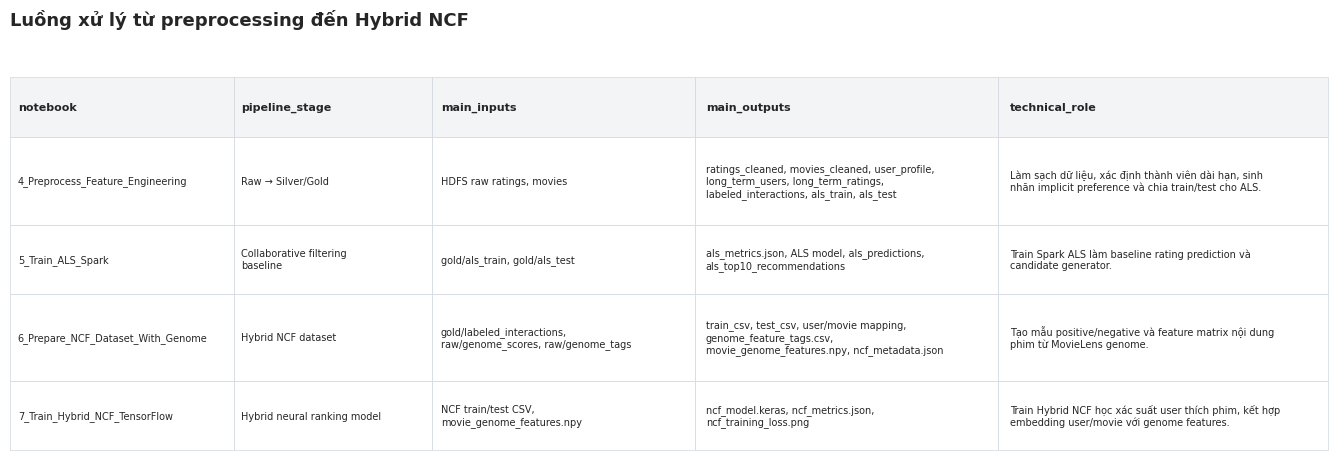

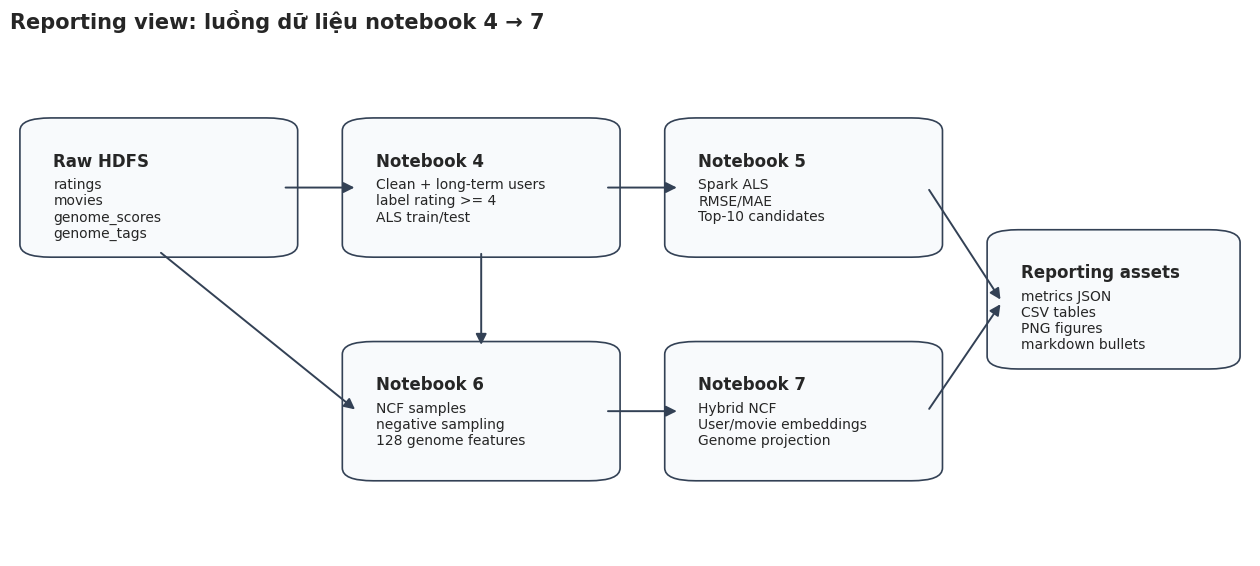

PosixPath('/workspace/outputs/reporting/reporting_layer_4_5_6_7_modeling_pipeline/figures/modeling_pipeline_architecture_flow.png')

In [5]:
pipeline_steps = pd.DataFrame([
    {
        "notebook": "4_Preprocess_Feature_Engineering",
        "pipeline_stage": "Raw → Silver/Gold",
        "main_inputs": "HDFS raw ratings, movies",
        "main_outputs": "ratings_cleaned, movies_cleaned, user_profile, long_term_users, long_term_ratings, labeled_interactions, als_train, als_test",
        "technical_role": "Làm sạch dữ liệu, xác định thành viên dài hạn, sinh nhãn implicit preference và chia train/test cho ALS.",
    },
    {
        "notebook": "5_Train_ALS_Spark",
        "pipeline_stage": "Collaborative filtering baseline",
        "main_inputs": "gold/als_train, gold/als_test",
        "main_outputs": "als_metrics.json, ALS model, als_predictions, als_top10_recommendations",
        "technical_role": "Train Spark ALS làm baseline rating prediction và candidate generator.",
    },
    {
        "notebook": "6_Prepare_NCF_Dataset_With_Genome",
        "pipeline_stage": "Hybrid NCF dataset",
        "main_inputs": "gold/labeled_interactions, raw/genome_scores, raw/genome_tags",
        "main_outputs": "train_csv, test_csv, user/movie mapping, genome_feature_tags.csv, movie_genome_features.npy, ncf_metadata.json",
        "technical_role": "Tạo mẫu positive/negative và feature matrix nội dung phim từ MovieLens genome.",
    },
    {
        "notebook": "7_Train_Hybrid_NCF_TensorFlow",
        "pipeline_stage": "Hybrid neural ranking model",
        "main_inputs": "NCF train/test CSV, movie_genome_features.npy",
        "main_outputs": "ncf_model.keras, ncf_metrics.json, ncf_training_loss.png",
        "technical_role": "Train Hybrid NCF học xác suất user thích phim, kết hợp embedding user/movie với genome features.",
    },
])

save_table(pipeline_steps, "modeling_pipeline_steps")
display_df(pipeline_steps, "Modeling pipeline steps: notebooks 4 → 7", max_rows=10)
save_table_image(
    pipeline_steps,
    "modeling_pipeline_steps_table",
    "Luồng xử lý từ preprocessing đến Hybrid NCF",
    max_rows=10,
    wrap_width=34,
    font_size=7,
    scale_y=1.35,
    wrap_widths={
        "notebook": 28,
        "pipeline_stage": 28,
        "main_inputs": 42,
        "main_outputs": 48,
        "technical_role": 54,
    },
    col_widths=[0.17, 0.15, 0.20, 0.23, 0.25],
)

# Architecture flow diagram.
fig, ax = plt.subplots(figsize=(16, 6.6))
ax.axis("off")

boxes = [
    {"xy": (0.02, 0.60), "w": 0.20, "h": 0.25, "title": "Raw HDFS", "body": "ratings\nmovies\ngenome_scores\ngenome_tags"},
    {"xy": (0.28, 0.60), "w": 0.20, "h": 0.25, "title": "Notebook 4", "body": "Clean + long-term users\nlabel rating >= 4\nALS train/test"},
    {"xy": (0.54, 0.60), "w": 0.20, "h": 0.25, "title": "Notebook 5", "body": "Spark ALS\nRMSE/MAE\nTop-10 candidates"},
    {"xy": (0.28, 0.16), "w": 0.20, "h": 0.25, "title": "Notebook 6", "body": "NCF samples\nnegative sampling\n128 genome features"},
    {"xy": (0.54, 0.16), "w": 0.20, "h": 0.25, "title": "Notebook 7", "body": "Hybrid NCF\nUser/movie embeddings\nGenome projection"},
    {"xy": (0.80, 0.38), "w": 0.18, "h": 0.25, "title": "Reporting assets", "body": "metrics JSON\nCSV tables\nPNG figures\nmarkdown bullets"},
]

for b in boxes:
    x, y = b["xy"]
    patch = FancyBboxPatch(
        (x, y), b["w"], b["h"],
        boxstyle="round,pad=0.012,rounding_size=0.025",
        linewidth=1.2,
        edgecolor="#334155",
        facecolor="#F8FAFC",
    )
    ax.add_patch(patch)
    ax.text(x + 0.015, y + b["h"] - 0.055, b["title"], fontsize=12, fontweight="bold", ha="left", va="top")
    ax.text(x + 0.015, y + b["h"] - 0.105, b["body"], fontsize=10, ha="left", va="top")

arrows = [
    ((0.22, 0.725), (0.28, 0.725)),
    ((0.48, 0.725), (0.54, 0.725)),
    ((0.38, 0.60), (0.38, 0.41)),
    ((0.48, 0.285), (0.54, 0.285)),
    ((0.74, 0.725), (0.80, 0.50)),
    ((0.74, 0.285), (0.80, 0.50)),
    ((0.12, 0.60), (0.28, 0.285)),
]
for start, end in arrows:
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle="-|>", mutation_scale=16, linewidth=1.4, color="#334155"))

ax.set_title("Reporting view: luồng dữ liệu notebook 4 → 7", fontsize=15, fontweight="bold", loc="left", pad=14)
save_figure("modeling_pipeline_architecture_flow")

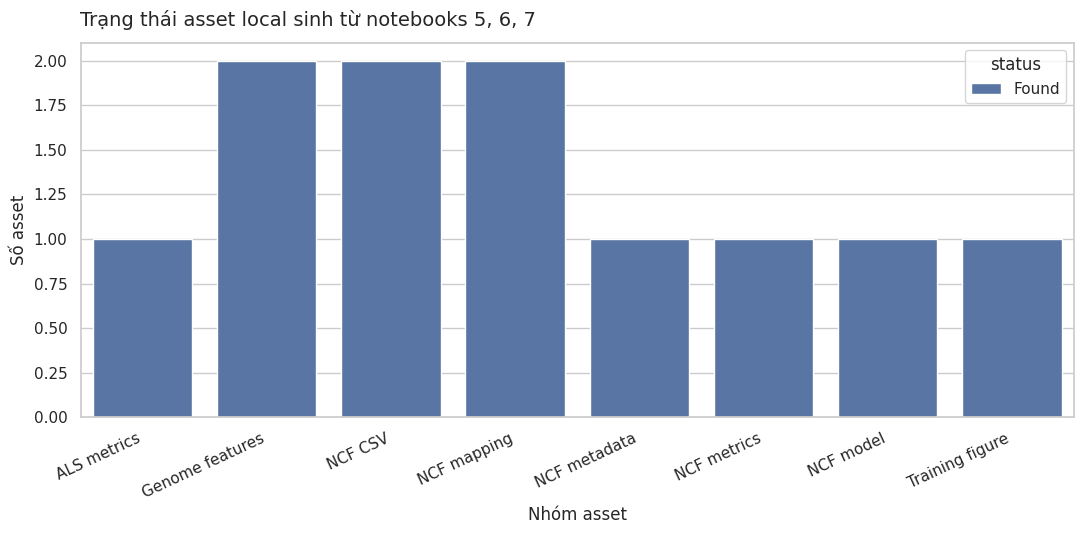

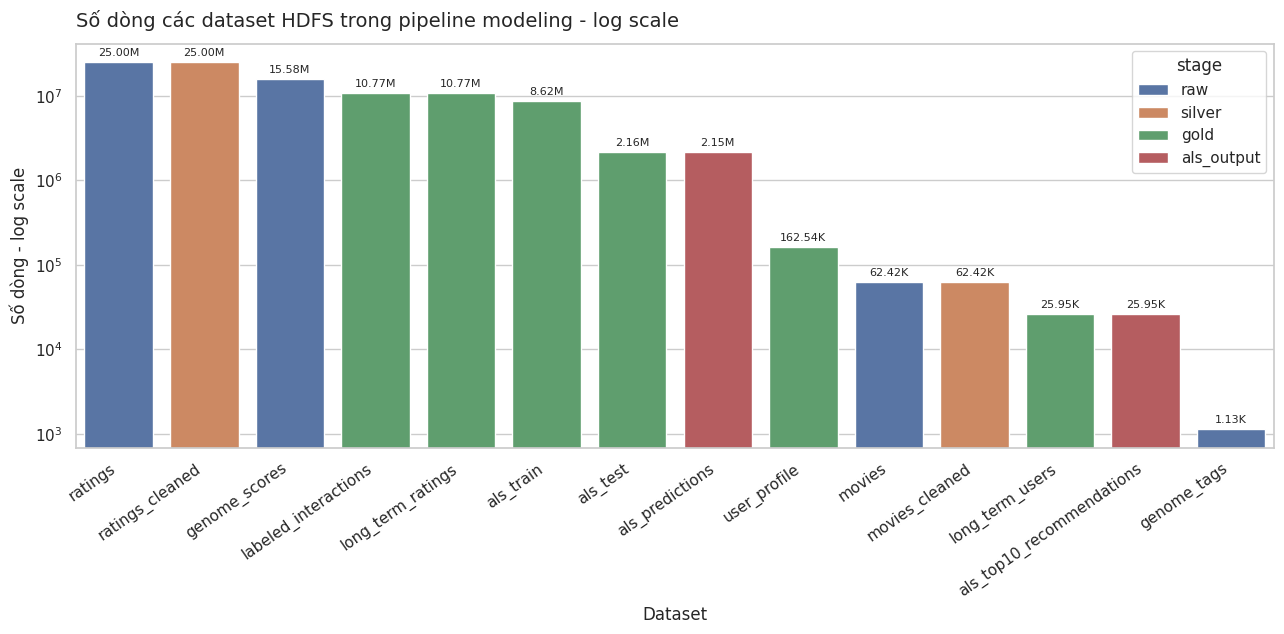

### Combined modeling asset inventory

,asset_group,asset,path,exists,size_mb,source_type,rows,columns
0,ALS metrics,als_metrics.json,/workspace/outputs/metrics/als_metrics.json,True,0.000000,local_file,nan,nan
1,NCF metrics,ncf_metrics.json,/workspace/outputs/metrics/ncf_metrics.json,True,0.000000,local_file,nan,nan
2,NCF metadata,ncf_metadata.json,/workspace/outputs/ncf/ncf_metadata.json,True,0.001000,local_file,nan,nan
3,NCF CSV,train_csv/part-*.csv,/workspace/outputs/ncf/train_csv,True,39.306000,local_file,nan,nan
4,NCF CSV,test_csv/part-*.csv,/workspace/outputs/ncf/test_csv,True,9.834000,local_file,nan,nan
5,NCF mapping,user_mapping_csv/part-*.csv,/workspace/outputs/ncf/user_mapping_csv,True,0.294000,local_file,nan,nan
6,NCF mapping,movie_mapping_csv/part-*.csv,/workspace/outputs/ncf/movie_mapping_csv,True,0.302000,local_file,nan,nan
7,Genome features,genome_feature_tags.csv,/workspace/outputs/ncf/genome_feature_tags.csv,True,0.005000,local_file,nan,nan
8,Genome features,movie_genome_features.npy,/workspace/outputs/ncf/movie_genome_features.npy,True,13.232000,local_file,nan,nan
9,NCF model,ncf_model.keras,/workspace/models/ncf/ncf_model.keras,True,52.644000,local_file,nan,nan


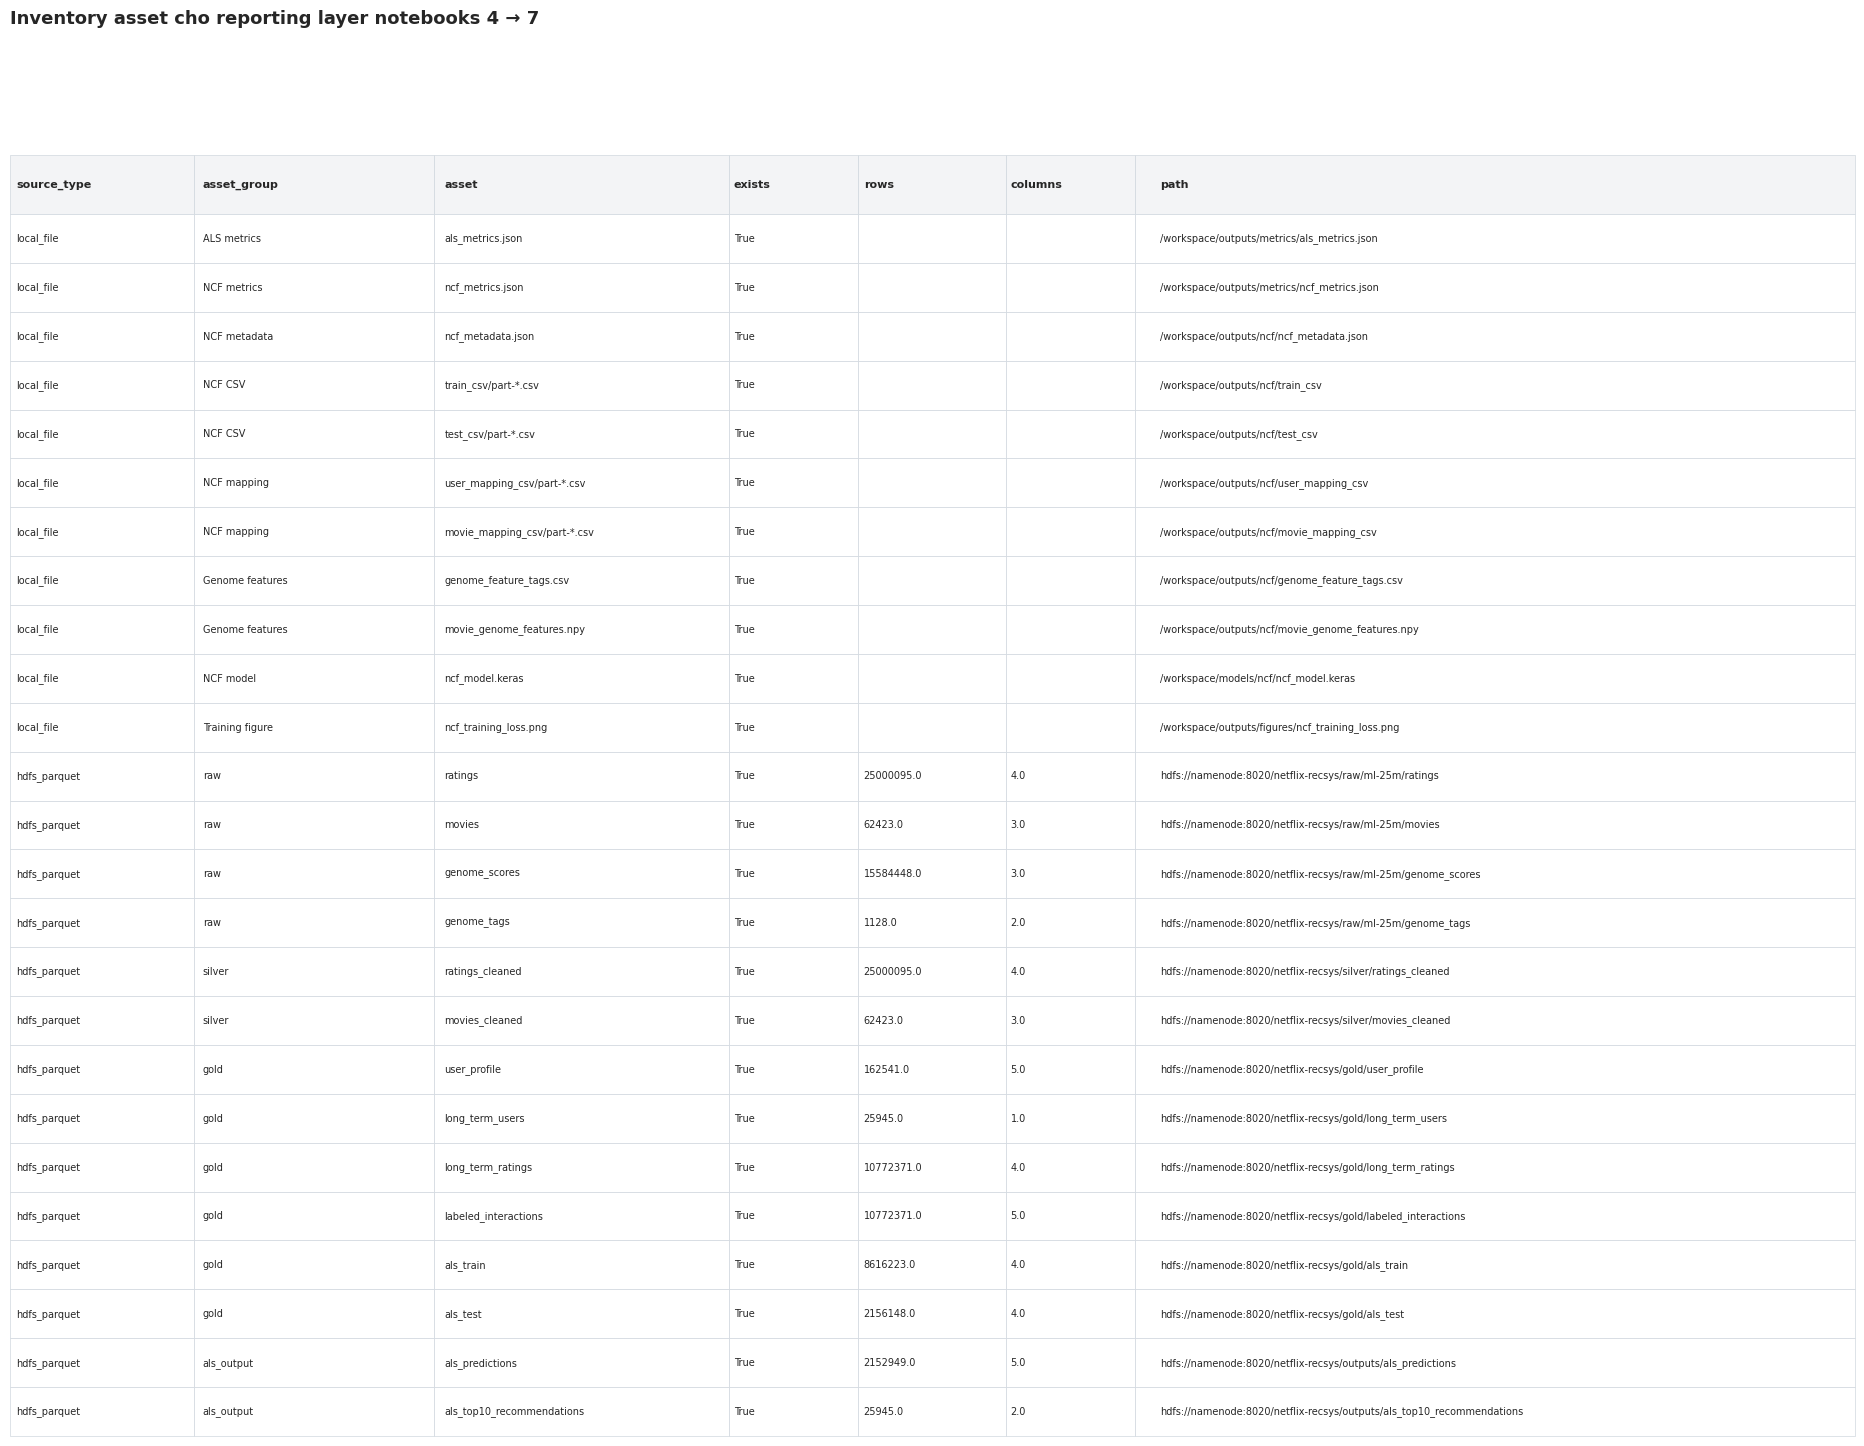

PosixPath('/workspace/outputs/reporting/reporting_layer_4_5_6_7_modeling_pipeline/figures/combined_modeling_asset_inventory_table.png')

In [6]:
# Local asset status chart.
if len(local_asset_inventory_df):
    status_df = local_asset_inventory_df.copy()
    status_df["status"] = np.where(status_df["exists"], "Found", "Missing")
    status_count_df = status_df.groupby(["asset_group", "status"], as_index=False).size()

    plt.figure(figsize=(11, 5.5))
    if SEABORN_AVAILABLE:
        ax = sns.barplot(data=status_count_df, x="asset_group", y="size", hue="status")
    else:
        ax = status_count_df.pivot(index="asset_group", columns="status", values="size").fillna(0).plot(kind="bar").get_figure().axes[0]
    ax.set_title("Trạng thái asset local sinh từ notebooks 5, 6, 7", fontsize=14, loc="left", pad=12)
    ax.set_xlabel("Nhóm asset")
    ax.set_ylabel("Số asset")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    save_figure("local_modeling_asset_status")

# HDFS count chart.
plot_counts_df = hdfs_counts_df.dropna(subset=["rows"]).copy()
if len(plot_counts_df):
    plot_counts_df = plot_counts_df.sort_values("rows", ascending=False)
    plt.figure(figsize=(13, 6.5))
    if SEABORN_AVAILABLE:
        ax = sns.barplot(data=plot_counts_df, x="name", y="rows", hue="stage", dodge=False)
    else:
        ax = plt.gca()
        ax.bar(plot_counts_df["name"], plot_counts_df["rows"])
    ax.set_yscale("log")
    ax.set_title("Số dòng các dataset HDFS trong pipeline modeling - log scale", fontsize=14, loc="left", pad=12)
    ax.set_xlabel("Dataset")
    ax.set_ylabel("Số dòng - log scale")
    for container in ax.containers:
        try:
            ax.bar_label(container, labels=[compact_number(v) for v in container.datavalues], padding=3, fontsize=8)
        except Exception:
            pass
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    save_figure("hdfs_modeling_dataset_row_counts_logscale")
else:
    display(Markdown("_Chưa có row-count HDFS để vẽ. Nếu đang chạy ngoài Docker/Spark, hãy chạy lại khi cluster bật._"))

# Combined inventory table image.
combined_inventory_df = pd.concat([
    local_asset_inventory_df.assign(source_type="local_file"),
    hdfs_counts_df[["stage", "name", "path", "exists", "rows", "columns"]].rename(columns={"name": "asset", "stage": "asset_group"}).assign(source_type="hdfs_parquet"),
], ignore_index=True, sort=False)

save_table(combined_inventory_df, "combined_modeling_asset_inventory")
display_df(combined_inventory_df, "Combined modeling asset inventory", max_rows=50)
save_table_image(
    combined_inventory_df[["source_type", "asset_group", "asset", "exists", "rows", "columns", "path"]],
    "combined_modeling_asset_inventory_table",
    "Inventory asset cho reporting layer notebooks 4 → 7",
    max_rows=28,
    wrap_width=42,
    font_size=7,
    scale_y=1.35,
    wrap_widths={"source_type": 16, "asset_group": 22, "asset": 32, "exists": 10, "rows": 14, "columns": 12, "path": 60},
    col_widths=[0.10, 0.13, 0.16, 0.07, 0.08, 0.07, 0.39],
)

### Notebook 4 KPIs: preprocessing and feature engineering

,kpi,value,technical_meaning,display_value
0,Raw ratings,25000095,Nguồn tương tác gốc user-movie trước khi clean.,"25,000,095"
1,Ratings cleaned,25000095,"Rating đã cast kiểu dữ liệu, drop null và lọc rating hợp lệ 0.5–5.0.","25,000,095"
2,Raw movies,62423,Catalogue phim gốc.,"62,423"
3,Movies cleaned,62423,Movie metadata đã chuẩn hóa movieId/title/genres.,"62,423"
4,User profiles,162541,"Bảng hồ sơ user gồm số rating, ngày đầu/cuối và active_days.","162,541"
5,Long-term users,25945,User có tối thiểu 50 ratings và active_days >= 180.,"25,945"
6,Long-term ratings,10772371,"Tập rating của nhóm thành viên dài hạn, là trọng tâm đề tài.","10,772,371"
7,Labeled interactions,10772371,Nhãn binary cho NCF: rating >= 4.0 là positive.,"10,772,371"
8,ALS train,8616223,Tập train ALS từ long_term_ratings.,"8,616,223"
9,ALS test,2156148,Tập test ALS từ long_term_ratings.,"2,156,148"


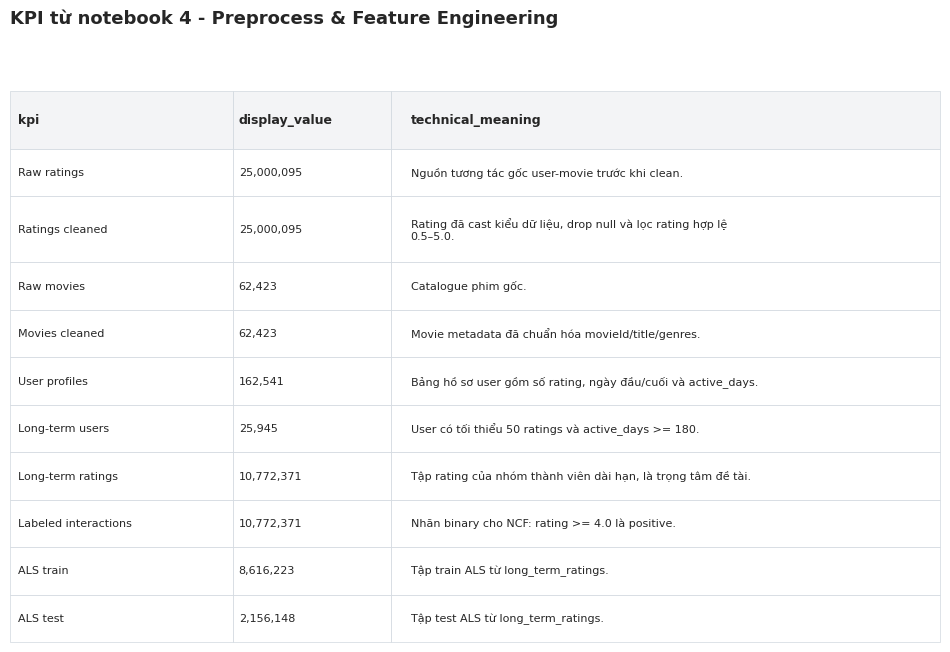

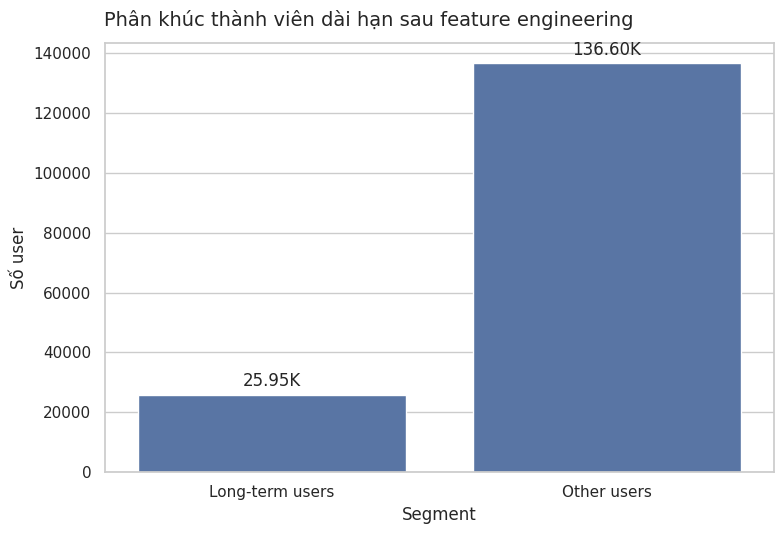

### ALS train/test split from notebook 4

,split,rows,ratio
0,train,8616223,0.799845
1,test,2156148,0.200155


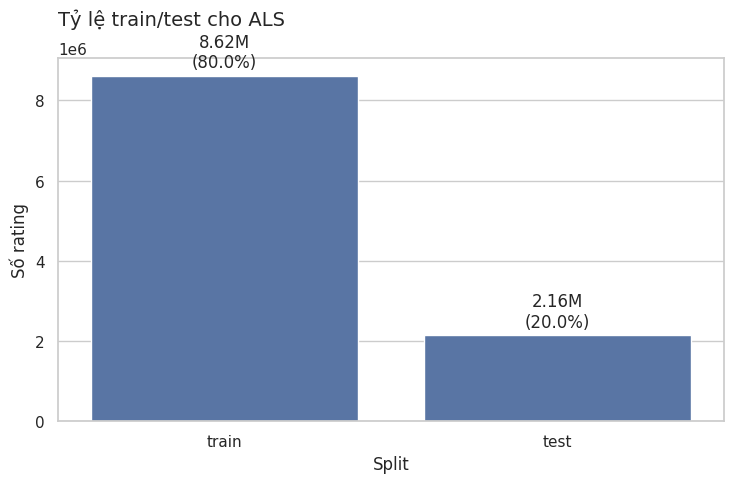

### Labeled interactions distribution

,label,count,label_name,ratio
0,0,5837766,0 - not positive,0.541920
1,1,4934605,1 - positive,0.458080


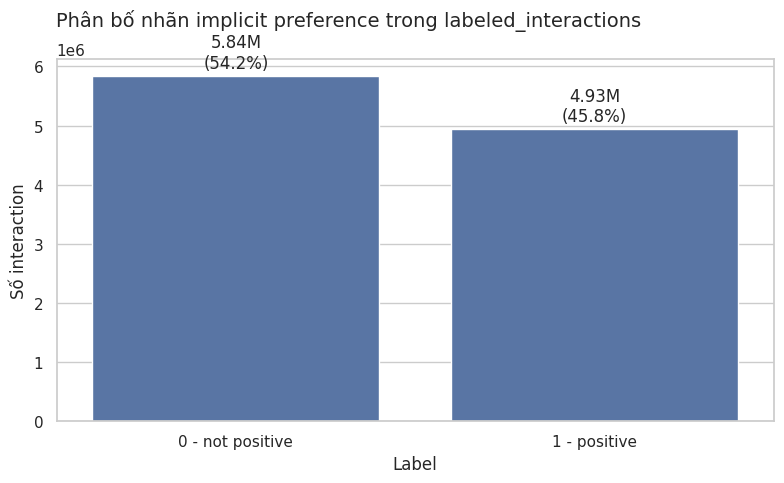

### User profile summary statistics

,summary,num_ratings,active_days
0,count,162541,162541
1,mean,153.80793153727367,221.41264050301154
2,stddev,268.04759008450094,716.5525208092298
3,min,20,0
4,25%,36,0
5,50%,71,0
6,75%,162,40
7,max,32202,8102


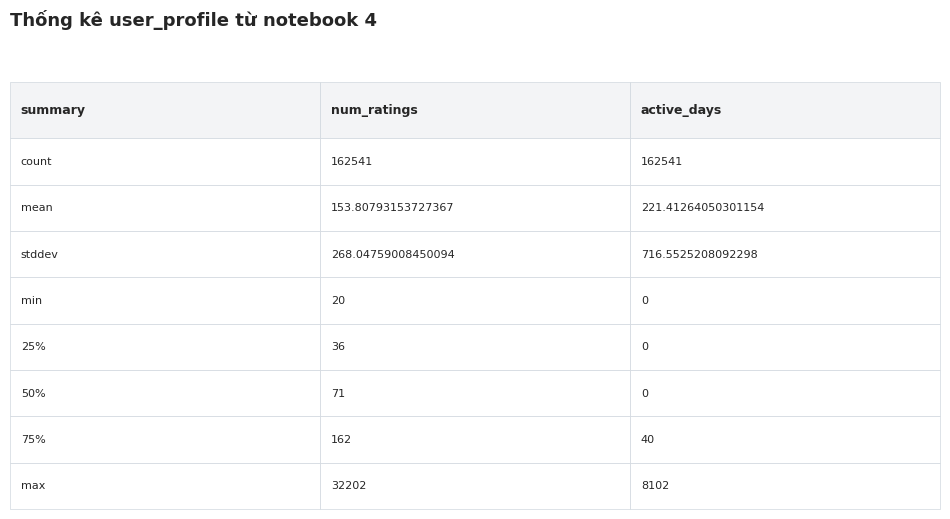

In [7]:
def get_count(name):
    if hdfs_counts_df is None or len(hdfs_counts_df) == 0:
        return None
    rows = hdfs_counts_df[hdfs_counts_df["name"] == name]
    if len(rows) == 0:
        return None
    value = rows.iloc[0].get("rows")
    return None if pd.isna(value) else int(value)

preprocess_kpis = pd.DataFrame([
    {"kpi": "Raw ratings", "value": get_count("ratings"), "technical_meaning": "Nguồn tương tác gốc user-movie trước khi clean."},
    {"kpi": "Ratings cleaned", "value": get_count("ratings_cleaned"), "technical_meaning": "Rating đã cast kiểu dữ liệu, drop null và lọc rating hợp lệ 0.5–5.0."},
    {"kpi": "Raw movies", "value": get_count("movies"), "technical_meaning": "Catalogue phim gốc."},
    {"kpi": "Movies cleaned", "value": get_count("movies_cleaned"), "technical_meaning": "Movie metadata đã chuẩn hóa movieId/title/genres."},
    {"kpi": "User profiles", "value": get_count("user_profile"), "technical_meaning": "Bảng hồ sơ user gồm số rating, ngày đầu/cuối và active_days."},
    {"kpi": "Long-term users", "value": get_count("long_term_users"), "technical_meaning": "User có tối thiểu 50 ratings và active_days >= 180."},
    {"kpi": "Long-term ratings", "value": get_count("long_term_ratings"), "technical_meaning": "Tập rating của nhóm thành viên dài hạn, là trọng tâm đề tài."},
    {"kpi": "Labeled interactions", "value": get_count("labeled_interactions"), "technical_meaning": "Nhãn binary cho NCF: rating >= 4.0 là positive."},
    {"kpi": "ALS train", "value": get_count("als_train"), "technical_meaning": "Tập train ALS từ long_term_ratings."},
    {"kpi": "ALS test", "value": get_count("als_test"), "technical_meaning": "Tập test ALS từ long_term_ratings."},
])
preprocess_kpis["display_value"] = preprocess_kpis["value"].map(human_int)

save_table(preprocess_kpis, "preprocessing_feature_engineering_kpis")
display_df(preprocess_kpis, "Notebook 4 KPIs: preprocessing and feature engineering", max_rows=20)
save_table_image(
    preprocess_kpis[["kpi", "display_value", "technical_meaning"]],
    "preprocessing_feature_engineering_kpis_table",
    "KPI từ notebook 4 - Preprocess & Feature Engineering",
    max_rows=20,
    wrap_width=38,
    font_size=8,
    scale_y=1.25,
    wrap_widths={"kpi": 24, "display_value": 18, "technical_meaning": 62},
    col_widths=[0.24, 0.17, 0.59],
)

# Long-term user ratio.
num_user_profile = get_count("user_profile")
num_long_term_users = get_count("long_term_users")
if num_user_profile and num_long_term_users is not None:
    segmentation_df = pd.DataFrame([
        {"segment": "Long-term users", "users": num_long_term_users},
        {"segment": "Other users", "users": max(num_user_profile - num_long_term_users, 0)},
    ])
    plt.figure(figsize=(8, 5.5))
    if SEABORN_AVAILABLE:
        ax = sns.barplot(data=segmentation_df, x="segment", y="users")
    else:
        ax = plt.gca(); ax.bar(segmentation_df["segment"], segmentation_df["users"])
    ax.set_title("Phân khúc thành viên dài hạn sau feature engineering", fontsize=14, loc="left", pad=12)
    ax.set_xlabel("Segment")
    ax.set_ylabel("Số user")
    for container in ax.containers:
        ax.bar_label(container, labels=[compact_number(v) for v in segmentation_df["users"]], padding=3)
    plt.tight_layout()
    save_figure("long_term_user_segmentation_bar")

# ALS train/test split.
als_train_count = get_count("als_train")
als_test_count = get_count("als_test")
if als_train_count is not None and als_test_count is not None:
    als_split_df = pd.DataFrame([
        {"split": "train", "rows": als_train_count},
        {"split": "test", "rows": als_test_count},
    ])
    als_split_df["ratio"] = als_split_df["rows"] / als_split_df["rows"].sum()
    save_table(als_split_df, "als_train_test_split")
    display_df(als_split_df, "ALS train/test split from notebook 4", max_rows=10)

    plt.figure(figsize=(7.5, 5))
    if SEABORN_AVAILABLE:
        ax = sns.barplot(data=als_split_df, x="split", y="rows")
    else:
        ax = plt.gca(); ax.bar(als_split_df["split"], als_split_df["rows"])
    ax.set_title("Tỷ lệ train/test cho ALS", fontsize=14, loc="left", pad=12)
    ax.set_xlabel("Split")
    ax.set_ylabel("Số rating")
    for container in ax.containers:
        ax.bar_label(container, labels=[f"{compact_number(v)}\n({p*100:.1f}%)" for v, p in zip(als_split_df["rows"], als_split_df["ratio"])], padding=3)
    plt.tight_layout()
    save_figure("als_train_test_split_bar")

# Label distribution for NCF source interactions.
if len(label_distribution_df):
    label_plot_df = label_distribution_df.copy()
    label_plot_df["label_name"] = label_plot_df["label"].map({0: "0 - not positive", 1: "1 - positive"}).fillna(label_plot_df["label"].astype(str))
    label_plot_df["ratio"] = label_plot_df["count"] / label_plot_df["count"].sum()
    save_table(label_plot_df, "labeled_interactions_label_distribution_with_ratio")
    display_df(label_plot_df, "Labeled interactions distribution", max_rows=10)

    plt.figure(figsize=(8, 5))
    if SEABORN_AVAILABLE:
        ax = sns.barplot(data=label_plot_df, x="label_name", y="count")
    else:
        ax = plt.gca(); ax.bar(label_plot_df["label_name"], label_plot_df["count"])
    ax.set_title("Phân bố nhãn implicit preference trong labeled_interactions", fontsize=14, loc="left", pad=12)
    ax.set_xlabel("Label")
    ax.set_ylabel("Số interaction")
    for container in ax.containers:
        ax.bar_label(container, labels=[f"{compact_number(v)}\n({p*100:.1f}%)" for v, p in zip(label_plot_df["count"], label_plot_df["ratio"])], padding=3)
    plt.tight_layout()
    save_figure("labeled_interactions_label_distribution_bar")

# User profile summary table, if available.
if len(user_profile_stats_df):
    display_df(user_profile_stats_df, "User profile summary statistics", max_rows=20)
    save_table_image(
        user_profile_stats_df,
        "user_profile_summary_statistics_table",
        "Thống kê user_profile từ notebook 4",
        max_rows=10,
        wrap_width=20,
        font_size=8,
        scale_y=1.15,
    )

### ALS metrics and hyperparameters

,metric,value,display_value,interpretation
0,model,Spark ALS,Spark ALS,Tên mô hình baseline collaborative filtering.
1,rank,32,32,Số chiều latent factor trong ALS.
2,maxIter,8,8,Số vòng lặp train ALS.
3,regParam,0.080000,0.0800,Regularization để giảm overfitting.
4,rmse,0.778017,0.7780,Sai số bình phương trung bình căn bậc hai trên tập test; càng thấp càng tốt.
5,mae,0.604163,0.6042,Sai số tuyệt đối trung bình trên tập test; càng thấp càng tốt.


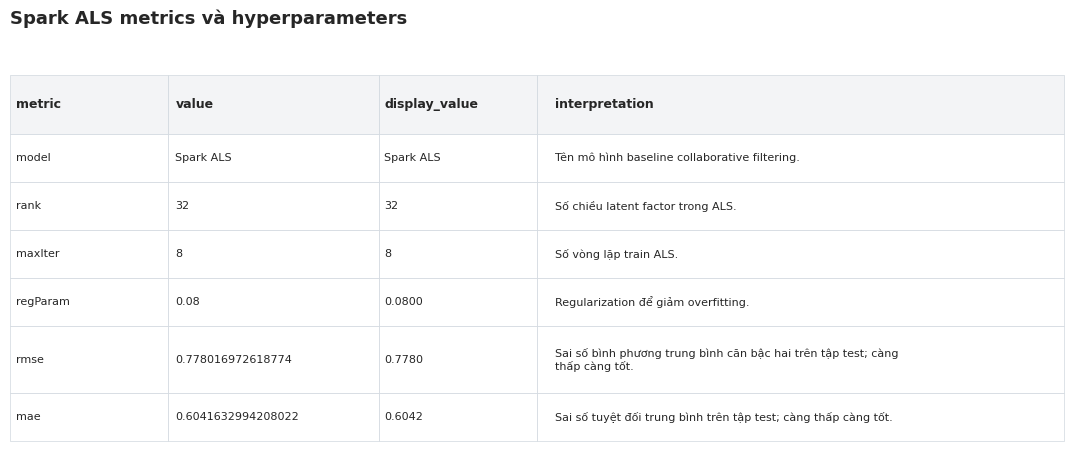

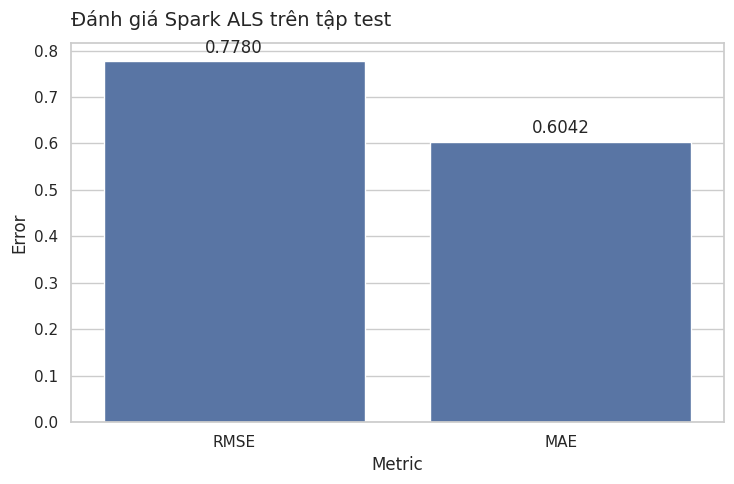

### ALS output volume

,asset,rows,meaning,display_rows
0,als_predictions,2152949,Prediction trên tập test sau khi drop cold-start/null.,"2,152,949"
1,als_top10_recommendations,25945,Top-10 candidate recommendations cho user mà ALS biết.,"25,945"


### ALS prediction summary statistics

,summary,rating,prediction
0,count,2152949,2152949
1,mean,3.462209741150394,3.315354503198166
2,stddev,1.0283075623457636,0.6274397698472671
3,min,0.5,0.08854653
4,25%,3.0,2.9432466
5,50%,3.5,3.3788648
6,75%,4.0,3.753377
7,max,5.0,6.040372


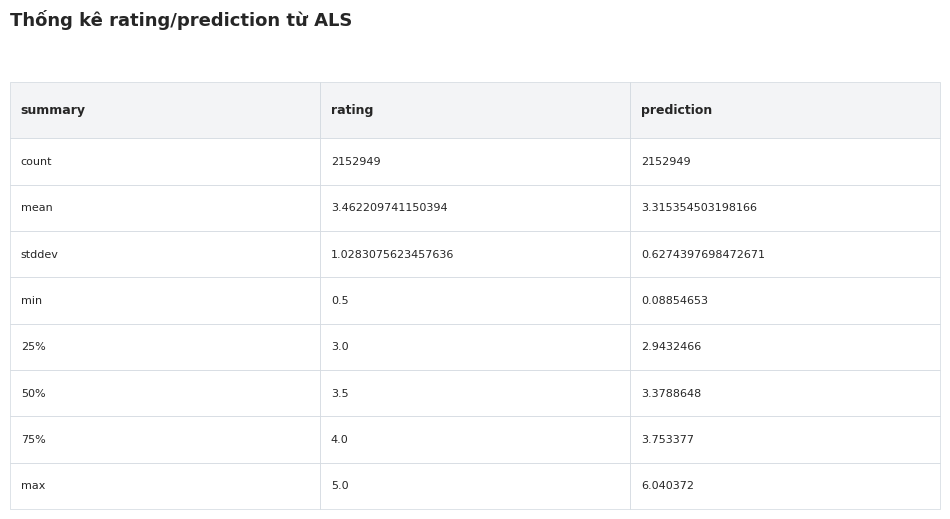

In [8]:
als_metric_rows = []
for key in ["model", "rank", "maxIter", "regParam", "rmse", "mae"]:
    if key in als_metrics:
        value = als_metrics.get(key)
        als_metric_rows.append({
            "metric": key,
            "value": value,
            "display_value": human_float(value, 4) if isinstance(value, (int, float)) and key in ["rmse", "mae", "regParam"] else str(value),
            "interpretation": {
                "model": "Tên mô hình baseline collaborative filtering.",
                "rank": "Số chiều latent factor trong ALS.",
                "maxIter": "Số vòng lặp train ALS.",
                "regParam": "Regularization để giảm overfitting.",
                "rmse": "Sai số bình phương trung bình căn bậc hai trên tập test; càng thấp càng tốt.",
                "mae": "Sai số tuyệt đối trung bình trên tập test; càng thấp càng tốt.",
            }.get(key, ""),
        })

als_metrics_df = pd.DataFrame(als_metric_rows)
save_table(als_metrics_df, "als_metrics_report_table")
display_df(als_metrics_df, "ALS metrics and hyperparameters", max_rows=20)
save_table_image(
    als_metrics_df,
    "als_metrics_report_table_image",
    "Spark ALS metrics và hyperparameters",
    max_rows=20,
    wrap_width=42,
    font_size=8,
    scale_y=1.20,
    wrap_widths={"metric": 18, "value": 24, "display_value": 18, "interpretation": 62},
    col_widths=[0.15, 0.20, 0.15, 0.50],
)

# RMSE/MAE chart if available.
als_eval_rows = []
for metric in ["rmse", "mae"]:
    value = als_metrics.get(metric)
    if isinstance(value, (int, float)):
        als_eval_rows.append({"metric": metric.upper(), "value": float(value)})

als_eval_df = pd.DataFrame(als_eval_rows)
if len(als_eval_df):
    plt.figure(figsize=(7.5, 5))
    if SEABORN_AVAILABLE:
        ax = sns.barplot(data=als_eval_df, x="metric", y="value")
    else:
        ax = plt.gca(); ax.bar(als_eval_df["metric"], als_eval_df["value"])
    ax.set_title("Đánh giá Spark ALS trên tập test", fontsize=14, loc="left", pad=12)
    ax.set_xlabel("Metric")
    ax.set_ylabel("Error")
    for container in ax.containers:
        ax.bar_label(container, labels=[f"{v:.4f}" for v in als_eval_df["value"]], padding=3)
    plt.tight_layout()
    save_figure("als_rmse_mae_bar")

# ALS output volume.
als_output_df = pd.DataFrame([
    {"asset": "als_predictions", "rows": get_count("als_predictions"), "meaning": "Prediction trên tập test sau khi drop cold-start/null."},
    {"asset": "als_top10_recommendations", "rows": get_count("als_top10_recommendations"), "meaning": "Top-10 candidate recommendations cho user mà ALS biết."},
])
als_output_df["display_rows"] = als_output_df["rows"].map(human_int)
save_table(als_output_df, "als_output_volume")
display_df(als_output_df, "ALS output volume", max_rows=10)

if len(als_prediction_stats_df):
    display_df(als_prediction_stats_df, "ALS prediction summary statistics", max_rows=20)
    save_table_image(
        als_prediction_stats_df,
        "als_prediction_summary_statistics_table",
        "Thống kê rating/prediction từ ALS",
        max_rows=10,
        wrap_width=20,
        font_size=8,
        scale_y=1.15,
    )

### NCF dataset artifacts from notebook 6

,dataset,rows,columns,source
0,ncf_train_csv,3199636,3,local CSV folder
1,ncf_test_csv,800478,3,local CSV folder
2,user_mapping_csv,25943,2,local CSV folder
3,movie_mapping_csv,27099,2,local CSV folder
4,genome_feature_tags,128,4,CSV
5,movie_genome_features,27099,128,NumPy matrix


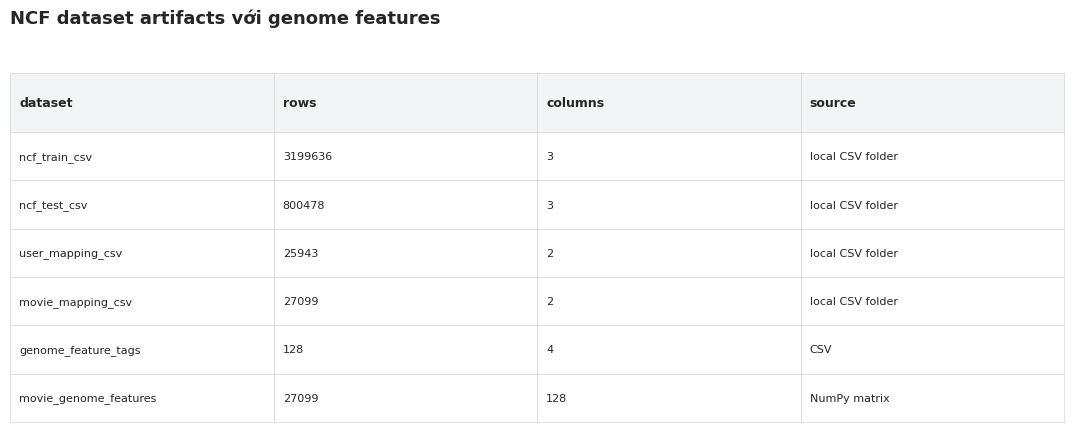

### NCF metadata

,metadata_key,value
0,num_users,25943
1,num_movies,27099
2,num_positive_samples,2000000
3,negative_sampling_ratio,1
4,label_rule,rating >= 4.0 => positive
5,model_input,"user_idx, movie_idx, label, movie_genome_features[movie_idx]"
6,uses_genome_features,True
7,genome_feature_dim,128
8,matrix_shape,"[27099, 128]"
9,feature_file,/workspace/outputs/ncf/movie_genome_features.npy


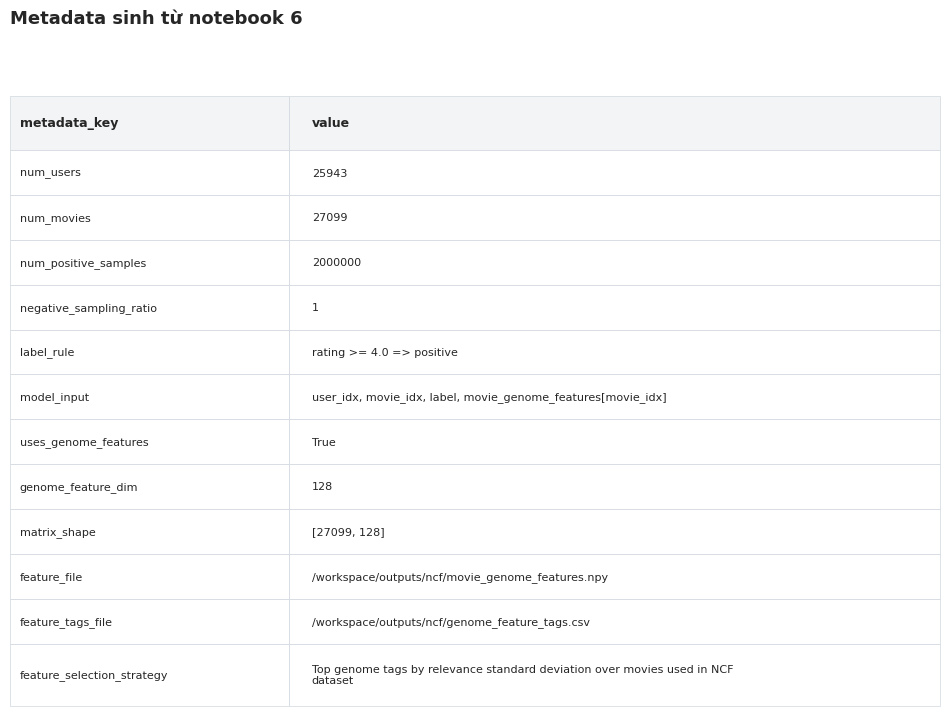

### NCF train/test label balance

,split,rows,positive,negative,positive_ratio,negative_ratio
0,train,3199636,1600352,1599284,0.500167,0.499833
1,test,800478,400676,399802,0.500546,0.499454


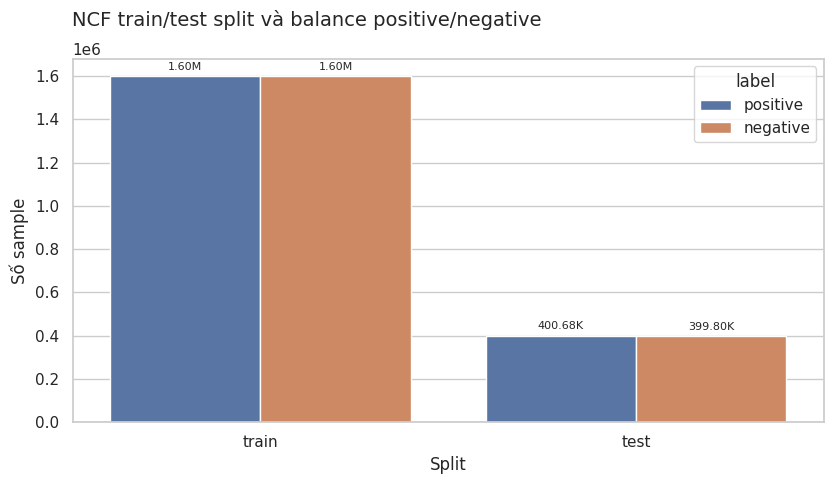

### Movie genome feature matrix statistics

,metric,value,meaning,display_value
0,Matrix rows - movies,27099.000000,Số movie_idx có vector genome trong NCF.,27099.0000
1,Matrix columns - genome feature dim,128.000000,Số genome tags được chọn làm content features.,128.0000
2,Non-zero values,1744000.000000,Số ô có relevance khác 0.,1744000.0000
3,Matrix density,0.502786,Tỷ lệ ô có relevance khác 0.,50.28%
4,Mean relevance,0.124897,Giá trị relevance trung bình trên toàn matrix.,0.1249
5,Max relevance,0.999750,Giá trị relevance cao nhất.,0.9998


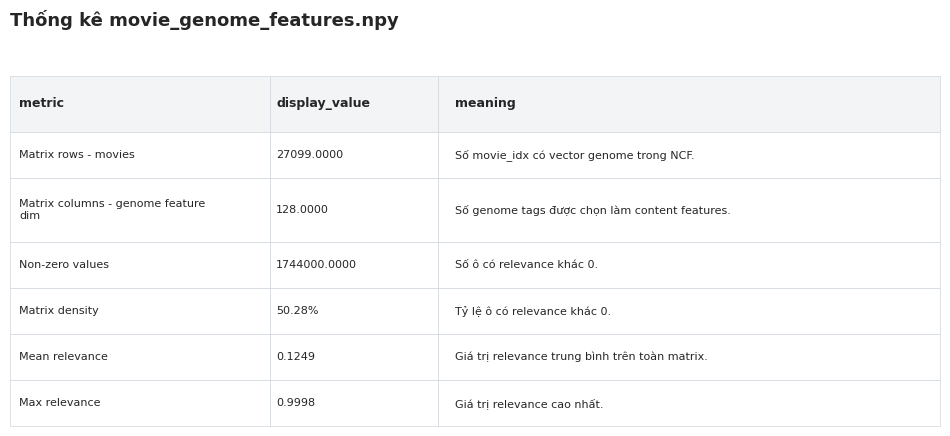

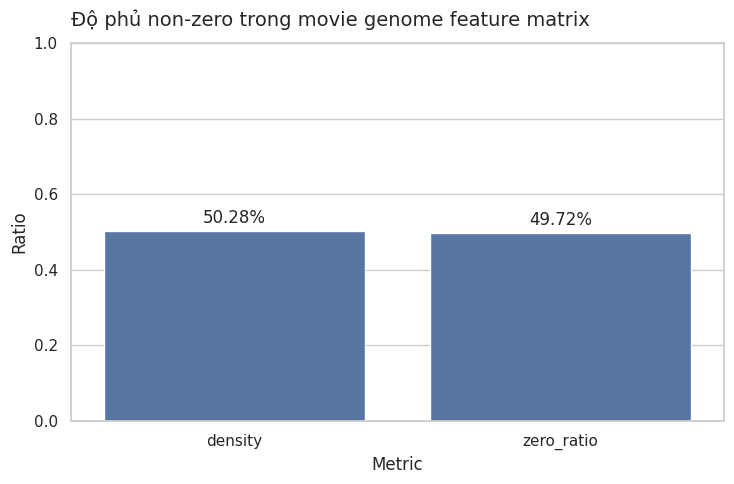

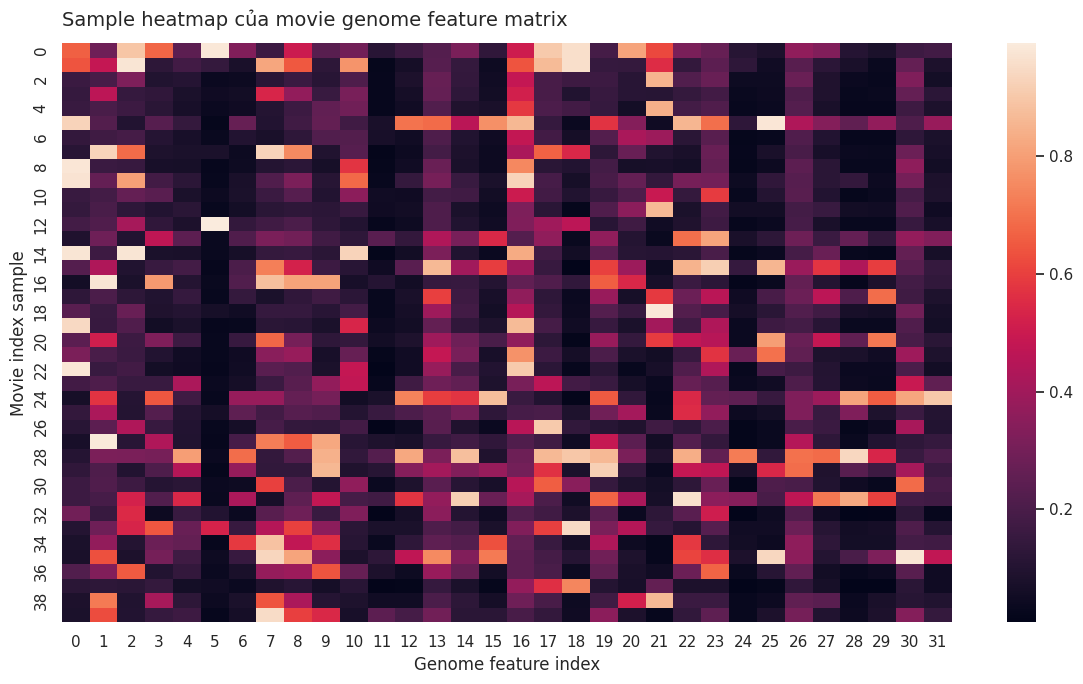

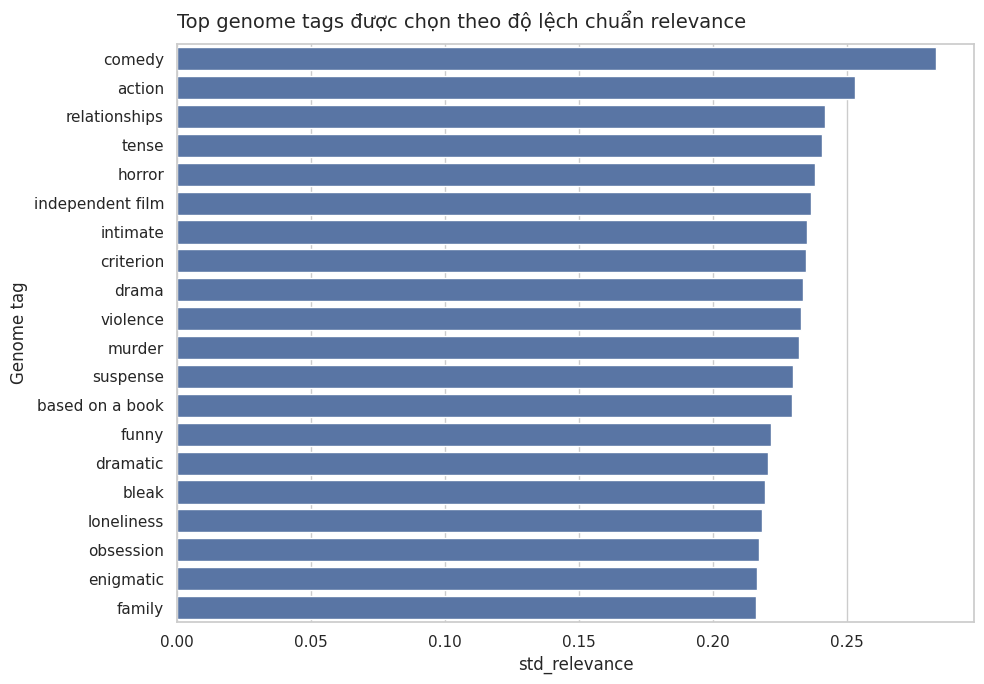

### Selected genome feature tags preview

,tagId,std_relevance,tag,feature_idx
0,19,0.253073,action,0
1,22,0.193131,adapted from:book,1
2,29,0.185471,adventure,2
3,30,0.193053,affectionate,3
4,46,0.182327,allegory,4
5,64,0.195771,animation,5
6,79,0.181540,artistic,6
7,107,0.229435,based on a book,7
8,113,0.193423,based on book,8
9,122,0.180760,beautifully filmed,9


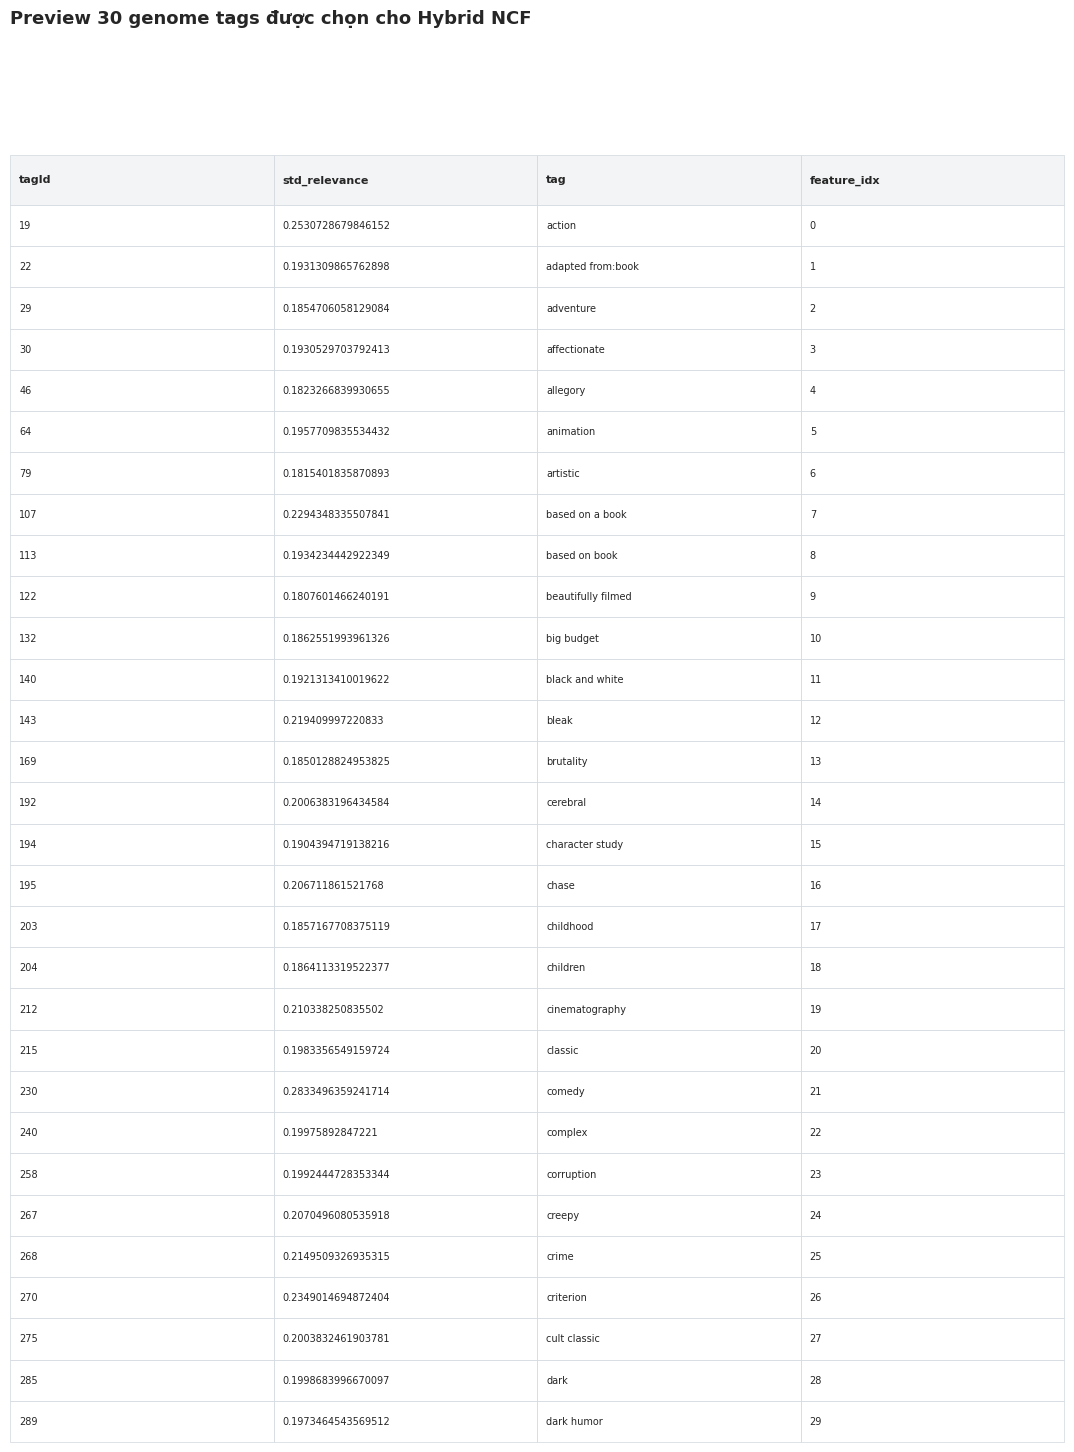

In [9]:
ncf_dataset_rows = []

if isinstance(ncf_train_df, pd.DataFrame) and len(ncf_train_df):
    ncf_dataset_rows.append({"dataset": "ncf_train_csv", "rows": len(ncf_train_df), "columns": len(ncf_train_df.columns), "source": "local CSV folder"})
if isinstance(ncf_test_df, pd.DataFrame) and len(ncf_test_df):
    ncf_dataset_rows.append({"dataset": "ncf_test_csv", "rows": len(ncf_test_df), "columns": len(ncf_test_df.columns), "source": "local CSV folder"})
if isinstance(user_mapping_df, pd.DataFrame) and len(user_mapping_df):
    ncf_dataset_rows.append({"dataset": "user_mapping_csv", "rows": len(user_mapping_df), "columns": len(user_mapping_df.columns), "source": "local CSV folder"})
if isinstance(movie_mapping_df, pd.DataFrame) and len(movie_mapping_df):
    ncf_dataset_rows.append({"dataset": "movie_mapping_csv", "rows": len(movie_mapping_df), "columns": len(movie_mapping_df.columns), "source": "local CSV folder"})
if len(genome_feature_tags_df):
    ncf_dataset_rows.append({"dataset": "genome_feature_tags", "rows": len(genome_feature_tags_df), "columns": len(genome_feature_tags_df.columns), "source": "CSV"})
if movie_genome_features is not None:
    ncf_dataset_rows.append({"dataset": "movie_genome_features", "rows": movie_genome_features.shape[0], "columns": movie_genome_features.shape[1], "source": "NumPy matrix"})

ncf_dataset_summary_df = pd.DataFrame(ncf_dataset_rows)
save_table(ncf_dataset_summary_df, "ncf_dataset_summary")
display_df(ncf_dataset_summary_df, "NCF dataset artifacts from notebook 6", max_rows=20)
save_table_image(
    ncf_dataset_summary_df,
    "ncf_dataset_summary_table",
    "NCF dataset artifacts với genome features",
    max_rows=20,
    wrap_width=30,
    font_size=8,
    scale_y=1.15,
)

# NCF metadata table.
ncf_metadata_rows = []
for key, value in ncf_metadata.items():
    ncf_metadata_rows.append({"metadata_key": key, "value": value})
ncf_metadata_df = pd.DataFrame(ncf_metadata_rows)
save_table(ncf_metadata_df, "ncf_metadata_report_table")
display_df(ncf_metadata_df, "NCF metadata", max_rows=50)
save_table_image(
    ncf_metadata_df,
    "ncf_metadata_report_table_image",
    "Metadata sinh từ notebook 6",
    max_rows=30,
    wrap_width=50,
    font_size=8,
    scale_y=1.2,
    wrap_widths={"metadata_key": 28, "value": 72},
    col_widths=[0.30, 0.70],
)

# Train/test and label balance from NCF CSVs.
ncf_split_rows = []
for split_name, df in [("train", ncf_train_df), ("test", ncf_test_df)]:
    if isinstance(df, pd.DataFrame) and len(df):
        ncf_split_rows.append({
            "split": split_name,
            "rows": len(df),
            "positive": int((df["label"] == 1).sum()) if "label" in df.columns else None,
            "negative": int((df["label"] == 0).sum()) if "label" in df.columns else None,
        })

ncf_split_df = pd.DataFrame(ncf_split_rows)
if len(ncf_split_df):
    ncf_split_df["positive_ratio"] = ncf_split_df["positive"] / ncf_split_df["rows"]
    ncf_split_df["negative_ratio"] = ncf_split_df["negative"] / ncf_split_df["rows"]
    save_table(ncf_split_df, "ncf_train_test_label_balance")
    display_df(ncf_split_df, "NCF train/test label balance", max_rows=10)

    split_long = ncf_split_df.melt(id_vars="split", value_vars=["positive", "negative"], var_name="label", value_name="sample_count")
    plt.figure(figsize=(8.5, 5))
    if SEABORN_AVAILABLE:
        ax = sns.barplot(data=split_long, x="split", y="sample_count", hue="label")
    else:
        ax = split_long.pivot(index="split", columns="label", values="sample_count").plot(kind="bar").get_figure().axes[0]
    ax.set_title("NCF train/test split và balance positive/negative", fontsize=14, loc="left", pad=12)
    ax.set_xlabel("Split")
    ax.set_ylabel("Số sample")
    for container in ax.containers:
        try:
            ax.bar_label(container, labels=[compact_number(v) for v in container.datavalues], padding=3, fontsize=8)
        except Exception:
            pass
    plt.tight_layout()
    save_figure("ncf_train_test_label_balance_bar")

# Genome feature matrix stats.
if movie_genome_feature_stats:
    matrix_stats_df = pd.DataFrame([
        {"metric": "Matrix rows - movies", "value": movie_genome_feature_stats.get("matrix_shape", [None, None])[0], "meaning": "Số movie_idx có vector genome trong NCF."},
        {"metric": "Matrix columns - genome feature dim", "value": movie_genome_feature_stats.get("matrix_shape", [None, None])[1], "meaning": "Số genome tags được chọn làm content features."},
        {"metric": "Non-zero values", "value": movie_genome_feature_stats.get("num_nonzero_values"), "meaning": "Số ô có relevance khác 0."},
        {"metric": "Matrix density", "value": movie_genome_feature_stats.get("density"), "meaning": "Tỷ lệ ô có relevance khác 0."},
        {"metric": "Mean relevance", "value": movie_genome_feature_stats.get("mean_relevance"), "meaning": "Giá trị relevance trung bình trên toàn matrix."},
        {"metric": "Max relevance", "value": movie_genome_feature_stats.get("max_relevance"), "meaning": "Giá trị relevance cao nhất."},
    ])
    matrix_stats_df["display_value"] = matrix_stats_df.apply(lambda r: human_pct(r["value"]) if r["metric"] == "Matrix density" else human_float(r["value"], 4) if isinstance(r["value"], float) else human_int(r["value"]), axis=1)
    save_table(matrix_stats_df, "movie_genome_feature_matrix_stats")
    display_df(matrix_stats_df, "Movie genome feature matrix statistics", max_rows=20)
    save_table_image(
        matrix_stats_df[["metric", "display_value", "meaning"]],
        "movie_genome_feature_matrix_stats_table",
        "Thống kê movie_genome_features.npy",
        max_rows=20,
        wrap_width=38,
        font_size=8,
        scale_y=1.15,
        wrap_widths={"metric": 32, "display_value": 18, "meaning": 64},
        col_widths=[0.28, 0.18, 0.54],
    )

    plt.figure(figsize=(7.5, 5))
    stats_plot = pd.DataFrame([
        {"metric": "density", "value": movie_genome_feature_stats.get("density")},
        {"metric": "zero_ratio", "value": 1 - movie_genome_feature_stats.get("density") if movie_genome_feature_stats.get("density") is not None else None},
    ]).dropna()
    if len(stats_plot):
        if SEABORN_AVAILABLE:
            ax = sns.barplot(data=stats_plot, x="metric", y="value")
        else:
            ax = plt.gca(); ax.bar(stats_plot["metric"], stats_plot["value"])
        ax.set_title("Độ phủ non-zero trong movie genome feature matrix", fontsize=14, loc="left", pad=12)
        ax.set_xlabel("Metric")
        ax.set_ylabel("Ratio")
        ax.set_ylim(0, 1)
        for container in ax.containers:
            ax.bar_label(container, labels=[f"{v*100:.2f}%" for v in stats_plot["value"]], padding=3)
        plt.tight_layout()
        save_figure("movie_genome_feature_matrix_density_bar")

# Heatmap sample from genome feature matrix.
if movie_genome_features is not None and movie_genome_features.size:
    sample_rows = min(40, movie_genome_features.shape[0])
    sample_cols = min(32, movie_genome_features.shape[1])
    sample_matrix = movie_genome_features[:sample_rows, :sample_cols]
    plt.figure(figsize=(12, 7))
    if SEABORN_AVAILABLE:
        ax = sns.heatmap(sample_matrix, cbar=True)
    else:
        ax = plt.gca(); im = ax.imshow(sample_matrix, aspect="auto"); plt.colorbar(im, ax=ax)
    ax.set_title("Sample heatmap của movie genome feature matrix", fontsize=14, loc="left", pad=12)
    ax.set_xlabel("Genome feature index")
    ax.set_ylabel("Movie index sample")
    plt.tight_layout()
    save_figure("movie_genome_feature_matrix_sample_heatmap")

# Selected genome tags by std_relevance.
if len(genome_feature_tags_df):
    feature_tags_plot_df = genome_feature_tags_df.copy()
    if "std_relevance" in feature_tags_plot_df.columns:
        top_tags_df = feature_tags_plot_df.sort_values("std_relevance", ascending=False).head(20)
        label_col = "tag" if "tag" in top_tags_df.columns else "tagId"
        plt.figure(figsize=(10, 7))
        if SEABORN_AVAILABLE:
            ax = sns.barplot(data=top_tags_df, y=label_col, x="std_relevance")
        else:
            ax = plt.gca(); ax.barh(top_tags_df[label_col].astype(str), top_tags_df["std_relevance"])
        ax.set_title("Top genome tags được chọn theo độ lệch chuẩn relevance", fontsize=14, loc="left", pad=12)
        ax.set_xlabel("std_relevance")
        ax.set_ylabel("Genome tag")
        plt.tight_layout()
        save_figure("selected_genome_tags_by_std_relevance_top20")

    display_df(genome_feature_tags_df.head(30), "Selected genome feature tags preview", max_rows=30)
    save_table_image(
        genome_feature_tags_df.head(30),
        "selected_genome_feature_tags_preview_table",
        "Preview 30 genome tags được chọn cho Hybrid NCF",
        max_rows=30,
        wrap_width=34,
        font_size=7,
        scale_y=1.15,
    )

### Hybrid NCF metrics and hyperparameters

,metric,value,display_value,interpretation
0,model,Hybrid Neural Collaborative Filtering with Movie Genome Features,Hybrid Neural Collaborative Filtering with Movie Genome Features,Tên mô hình hybrid neural recommender.
1,embedding_dim,64,64,Số chiều embedding user/movie.
2,genome_projection_dim,64,64,Số chiều dense projection cho genome features.
3,genome_feature_dim,128,128,Số genome feature đầu vào cho mỗi movie.
4,uses_genome_features,True,True,Xác nhận mô hình có dùng content feature từ genome-scores.
5,batch_size,8192,8192,Batch size khi train bằng TensorFlow.
6,accuracy,0.930179,0.9302,Tỷ lệ dự đoán đúng nhãn positive/negative.
7,auc,0.974705,0.9747,Khả năng phân biệt positive và negative; càng gần 1 càng tốt.
8,loss,0.198242,0.1982,Binary cross-entropy trên tập test; càng thấp càng tốt.


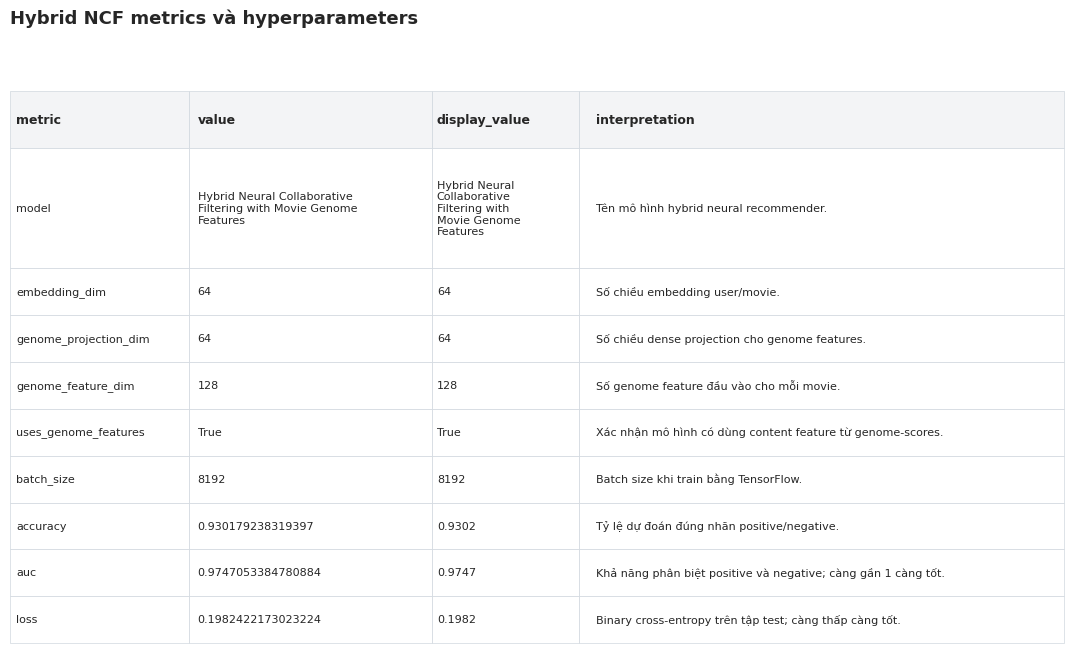

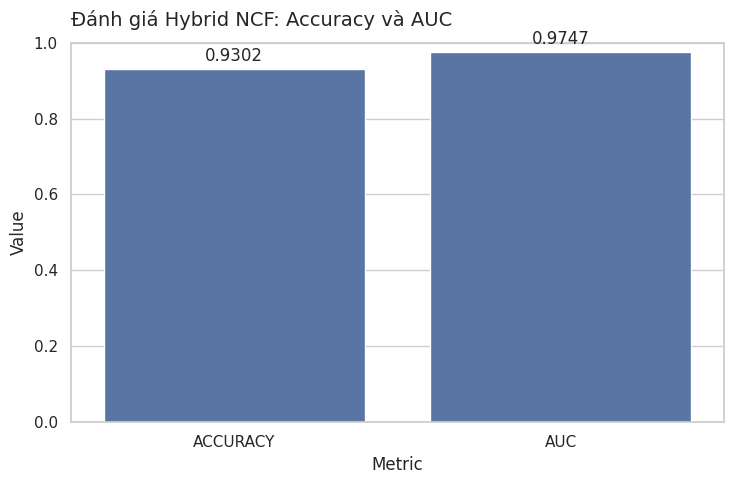

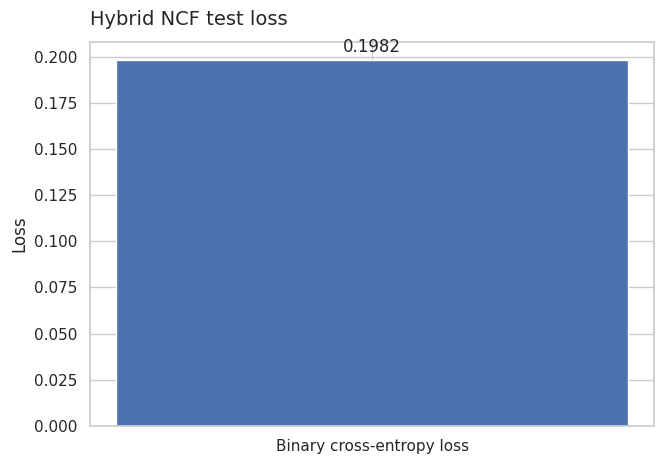

### Hybrid NCF architecture summary

,component,role,dimension
0,user_input,Input user_idx,scalar int32
1,movie_input,Input movie_idx,scalar int32
2,user_embedding,Learned collaborative signal for user,64
3,movie_embedding,Learned collaborative signal for movie,64
4,movie_genome_features,Frozen embedding initialized by movie_genome_features.npy,128
5,genome_projection,Dense projection from genome vector,64
6,MLP tower,Combine user/movie/genome signals and learn nonlinear preference,Dense 128 → 64 → 32
7,preference_probability,Sigmoid output for like probability,1


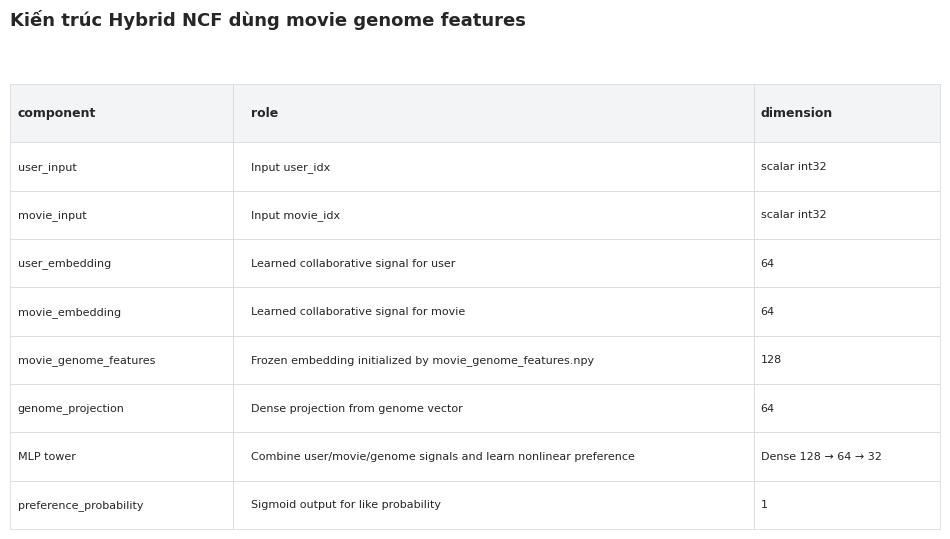

### Original training loss figure from notebook 7

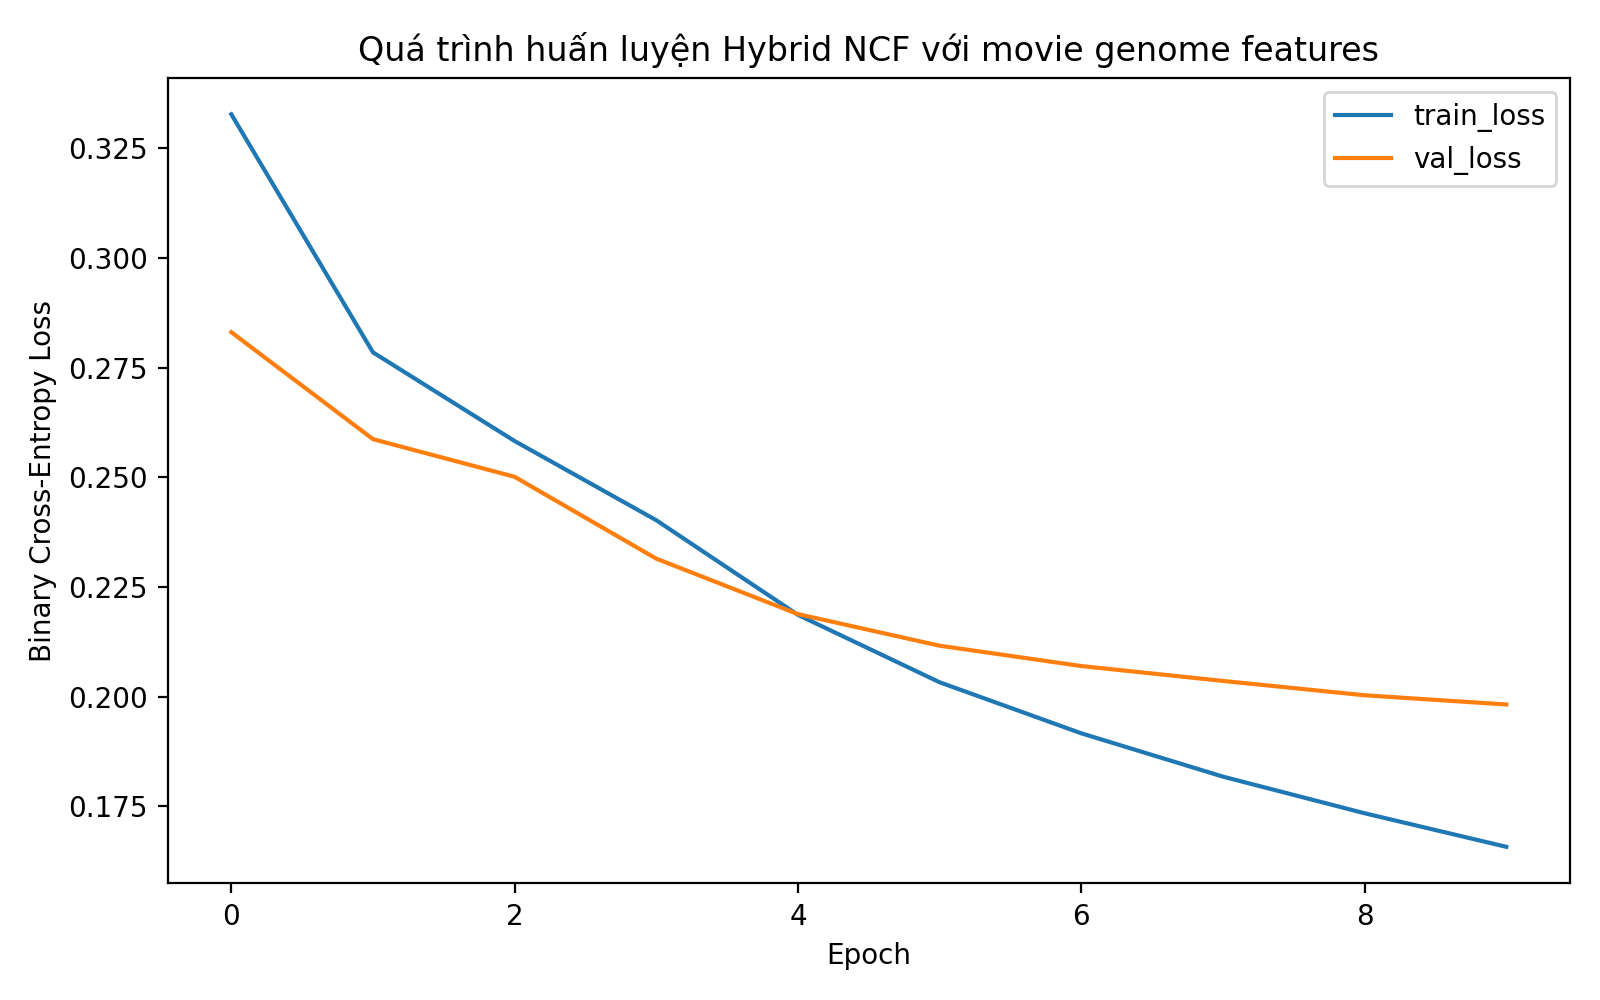

In [10]:
ncf_metric_rows = []
metric_interpretations = {
    "model": "Tên mô hình hybrid neural recommender.",
    "embedding_dim": "Số chiều embedding user/movie.",
    "genome_projection_dim": "Số chiều dense projection cho genome features.",
    "genome_feature_dim": "Số genome feature đầu vào cho mỗi movie.",
    "uses_genome_features": "Xác nhận mô hình có dùng content feature từ genome-scores.",
    "batch_size": "Batch size khi train bằng TensorFlow.",
    "loss": "Binary cross-entropy trên tập test; càng thấp càng tốt.",
    "accuracy": "Tỷ lệ dự đoán đúng nhãn positive/negative.",
    "auc": "Khả năng phân biệt positive và negative; càng gần 1 càng tốt.",
}

for key, value in ncf_metrics.items():
    ncf_metric_rows.append({
        "metric": key,
        "value": value,
        "display_value": human_float(value, 4) if isinstance(value, (int, float)) and key in ["loss", "accuracy", "auc"] else str(value),
        "interpretation": metric_interpretations.get(key, ""),
    })

ncf_metrics_df = pd.DataFrame(ncf_metric_rows)
save_table(ncf_metrics_df, "ncf_metrics_report_table")
display_df(ncf_metrics_df, "Hybrid NCF metrics and hyperparameters", max_rows=30)
save_table_image(
    ncf_metrics_df,
    "ncf_metrics_report_table_image",
    "Hybrid NCF metrics và hyperparameters",
    max_rows=30,
    wrap_width=44,
    font_size=8,
    scale_y=1.20,
    wrap_widths={"metric": 24, "value": 34, "display_value": 18, "interpretation": 62},
    col_widths=[0.17, 0.23, 0.14, 0.46],
)

# NCF accuracy and AUC chart.
ncf_quality_rows = []
for metric in ["accuracy", "auc"]:
    value = ncf_metrics.get(metric)
    if isinstance(value, (int, float)):
        ncf_quality_rows.append({"metric": metric.upper(), "value": float(value)})

ncf_quality_df = pd.DataFrame(ncf_quality_rows)
if len(ncf_quality_df):
    plt.figure(figsize=(7.5, 5))
    if SEABORN_AVAILABLE:
        ax = sns.barplot(data=ncf_quality_df, x="metric", y="value")
    else:
        ax = plt.gca(); ax.bar(ncf_quality_df["metric"], ncf_quality_df["value"])
    ax.set_ylim(0, 1)
    ax.set_title("Đánh giá Hybrid NCF: Accuracy và AUC", fontsize=14, loc="left", pad=12)
    ax.set_xlabel("Metric")
    ax.set_ylabel("Value")
    for container in ax.containers:
        ax.bar_label(container, labels=[f"{v:.4f}" for v in ncf_quality_df["value"]], padding=3)
    plt.tight_layout()
    save_figure("ncf_accuracy_auc_bar")

# NCF loss chart.
loss_value = ncf_metrics.get("loss")
if isinstance(loss_value, (int, float)):
    plt.figure(figsize=(6.8, 4.8))
    ax = plt.gca()
    ax.bar(["Binary cross-entropy loss"], [float(loss_value)])
    ax.set_title("Hybrid NCF test loss", fontsize=14, loc="left", pad=12)
    ax.set_ylabel("Loss")
    ax.bar_label(ax.containers[0], labels=[f"{float(loss_value):.4f}"], padding=3)
    plt.tight_layout()
    save_figure("ncf_test_loss_bar")

# Model architecture summary from notebook 7 design.
architecture_df = pd.DataFrame([
    {"component": "user_input", "role": "Input user_idx", "dimension": "scalar int32"},
    {"component": "movie_input", "role": "Input movie_idx", "dimension": "scalar int32"},
    {"component": "user_embedding", "role": "Learned collaborative signal for user", "dimension": ncf_metrics.get("embedding_dim")},
    {"component": "movie_embedding", "role": "Learned collaborative signal for movie", "dimension": ncf_metrics.get("embedding_dim")},
    {"component": "movie_genome_features", "role": "Frozen embedding initialized by movie_genome_features.npy", "dimension": ncf_metrics.get("genome_feature_dim")},
    {"component": "genome_projection", "role": "Dense projection from genome vector", "dimension": ncf_metrics.get("genome_projection_dim")},
    {"component": "MLP tower", "role": "Combine user/movie/genome signals and learn nonlinear preference", "dimension": "Dense 128 → 64 → 32"},
    {"component": "preference_probability", "role": "Sigmoid output for like probability", "dimension": "1"},
])
save_table(architecture_df, "hybrid_ncf_architecture_summary")
display_df(architecture_df, "Hybrid NCF architecture summary", max_rows=20)
save_table_image(
    architecture_df,
    "hybrid_ncf_architecture_summary_table",
    "Kiến trúc Hybrid NCF dùng movie genome features",
    max_rows=20,
    wrap_width=42,
    font_size=8,
    scale_y=1.20,
    wrap_widths={"component": 26, "role": 68, "dimension": 26},
    col_widths=[0.24, 0.56, 0.20],
)

# Copy training loss figure into reporting folder when available.
source_training_loss = FIGURES_SOURCE_DIR / "ncf_training_loss.png"
if source_training_loss.exists():
    copied = FIG_DIR / "ncf_training_loss_original.png"
    shutil.copy2(source_training_loss, copied)
    figure_exports["ncf_training_loss_original"] = str(copied)
    display(Markdown("### Original training loss figure from notebook 7"))
    display(Image(filename=str(copied), width=780))
else:
    display(Markdown("_Không tìm thấy `/workspace/outputs/figures/ncf_training_loss.png`. Nếu notebook 7 đã chạy, kiểm tra lại đường dẫn output._"))

### Storyboard dùng để viết chương Modeling Pipeline

,report_section,main_message,evidence,recommended_visual
0,Preprocessing & long-term users,Notebook 4 biến dữ liệu raw thành silver/gold tables và cô lập nhóm thành viên dài hạn đúng trọng tâm đề tài.,"Long-term users = 25,945, long-term ratings = 10,772,371.","preprocessing_feature_engineering_kpis_table.png, long_term_user_segmentation_bar.png"
1,Implicit preference labels,Rating được chuyển thành nhãn binary để huấn luyện mô hình ranking/classification kiểu NCF.,"Labeled interactions = 10,772,371; rule: rating >= 4.0 → positive.",labeled_interactions_label_distribution_bar.png
2,ALS baseline,Spark ALS là baseline collaborative filtering và cũng có thể dùng làm candidate generator.,"ALS train/test = 8,616,223/2,156,148, RMSE = 0.7780, MAE = 0.6042.","als_train_test_split_bar.png, als_rmse_mae_bar.png"
3,NCF dataset with genome,Notebook 6 nối collaborative signal với content signal từ MovieLens genome để chuẩn bị dữ liệu Hybrid NCF.,"NCF users = 25,943, movies = 27,099, genome dim = 128.","ncf_dataset_summary_table.png, selected_genome_tags_by_std_relevance_top20.png"
4,Hybrid NCF model,Notebook 7 train mô hình neural kết hợp user/movie embeddings với movie genome features để dự đoán xác suất yêu thích.,"Accuracy = 0.9302, AUC = 0.9747, Loss = 0.1982.","ncf_accuracy_auc_bar.png, ncf_test_loss_bar.png, hybrid_ncf_architecture_summary_table.png"
5,Technical asset completeness,"Reporting layer kiểm kê đầy đủ metrics, CSV, NumPy matrix, model file và HDFS parquet để tránh bỏ sót dữ liệu đã sinh.",Xem combined_modeling_asset_inventory.csv và bảng inventory PNG.,"combined_modeling_asset_inventory_table.png, local_modeling_asset_status.png"


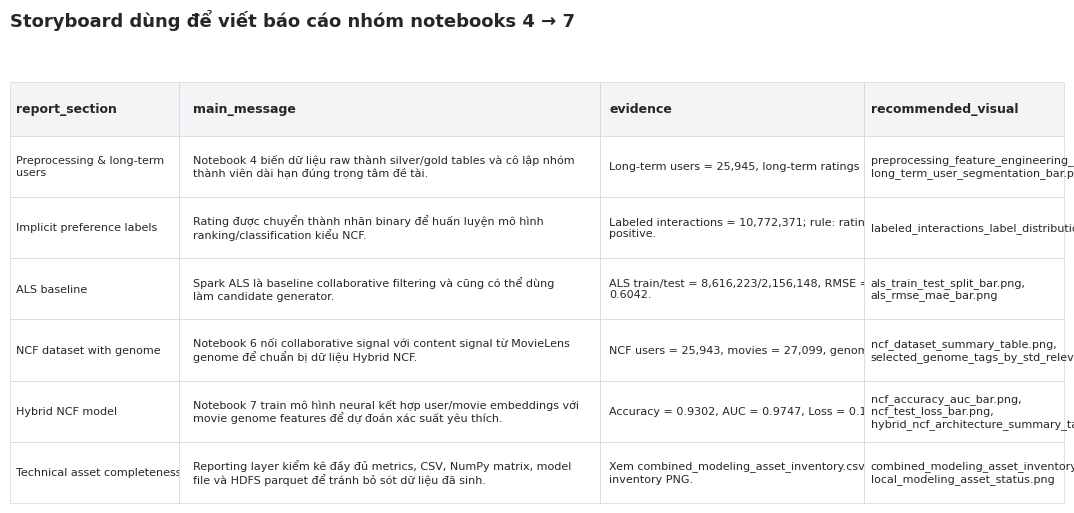

# Slide bullets — Modeling pipeline notebooks 4 → 7

## Preprocessing & long-term members
- Notebook 4 tạo silver/gold tables: ratings_cleaned, movies_cleaned, user_profile, long_term_users, long_term_ratings, labeled_interactions, als_train, als_test.
- Tiêu chí long-term user: **num_ratings >= 50** và **active_days >= 180**.
- Số long-term users: **25,945**; số long-term ratings: **10,772,371**.

## ALS baseline
- Notebook 5 train **Spark ALS** với rank = **32**, maxIter = **8**, regParam = **0.08**.
- Kết quả test: RMSE = **0.7780**, MAE = **0.6042**.
- Vai trò: baseline collaborative filtering và candidate generator cho bước demo cuối.

## NCF dataset with genome
- Notebook 6 tạo dữ liệu Hybrid NCF với positive samples từ labeled_interactions và negative sampling ratio = **1**.
- Movie genome feature matrix shape: **[27099, 128]**.
- Genome feature dim: **128**.

## Hybrid NCF
- Notebook 7 train mô hình Neural Collaborative Filtering có dùng movie genome features.
- Test metrics: Loss = **0.1982**, Accuracy = **0.9302**, AUC = **0.9747**.
- Vai trò: học xác suất user thích phim, phù hợp làm reranker sau ALS.

In [11]:
# Gather frequently used numbers from loaded assets.
num_long_term_users = get_count("long_term_users")
num_long_term_ratings = get_count("long_term_ratings")
num_labeled = get_count("labeled_interactions")
num_als_train = get_count("als_train")
num_als_test = get_count("als_test")
num_movies_ncf = ncf_metadata.get("num_movies")
num_users_ncf = ncf_metadata.get("num_users")
genome_dim = ncf_metadata.get("genome_feature_dim") or ncf_metrics.get("genome_feature_dim")

storyboard_df = pd.DataFrame([
    {
        "report_section": "Preprocessing & long-term users",
        "main_message": "Notebook 4 biến dữ liệu raw thành silver/gold tables và cô lập nhóm thành viên dài hạn đúng trọng tâm đề tài.",
        "evidence": f"Long-term users = {human_int(num_long_term_users)}, long-term ratings = {human_int(num_long_term_ratings)}.",
        "recommended_visual": "preprocessing_feature_engineering_kpis_table.png, long_term_user_segmentation_bar.png",
    },
    {
        "report_section": "Implicit preference labels",
        "main_message": "Rating được chuyển thành nhãn binary để huấn luyện mô hình ranking/classification kiểu NCF.",
        "evidence": f"Labeled interactions = {human_int(num_labeled)}; rule: rating >= 4.0 → positive.",
        "recommended_visual": "labeled_interactions_label_distribution_bar.png",
    },
    {
        "report_section": "ALS baseline",
        "main_message": "Spark ALS là baseline collaborative filtering và cũng có thể dùng làm candidate generator.",
        "evidence": f"ALS train/test = {human_int(num_als_train)}/{human_int(num_als_test)}, RMSE = {human_float(als_metrics.get('rmse'), 4)}, MAE = {human_float(als_metrics.get('mae'), 4)}.",
        "recommended_visual": "als_train_test_split_bar.png, als_rmse_mae_bar.png",
    },
    {
        "report_section": "NCF dataset with genome",
        "main_message": "Notebook 6 nối collaborative signal với content signal từ MovieLens genome để chuẩn bị dữ liệu Hybrid NCF.",
        "evidence": f"NCF users = {human_int(num_users_ncf)}, movies = {human_int(num_movies_ncf)}, genome dim = {human_int(genome_dim)}.",
        "recommended_visual": "ncf_dataset_summary_table.png, selected_genome_tags_by_std_relevance_top20.png",
    },
    {
        "report_section": "Hybrid NCF model",
        "main_message": "Notebook 7 train mô hình neural kết hợp user/movie embeddings với movie genome features để dự đoán xác suất yêu thích.",
        "evidence": f"Accuracy = {human_float(ncf_metrics.get('accuracy'), 4)}, AUC = {human_float(ncf_metrics.get('auc'), 4)}, Loss = {human_float(ncf_metrics.get('loss'), 4)}.",
        "recommended_visual": "ncf_accuracy_auc_bar.png, ncf_test_loss_bar.png, hybrid_ncf_architecture_summary_table.png",
    },
    {
        "report_section": "Technical asset completeness",
        "main_message": "Reporting layer kiểm kê đầy đủ metrics, CSV, NumPy matrix, model file và HDFS parquet để tránh bỏ sót dữ liệu đã sinh.",
        "evidence": "Xem combined_modeling_asset_inventory.csv và bảng inventory PNG.",
        "recommended_visual": "combined_modeling_asset_inventory_table.png, local_modeling_asset_status.png",
    },
])

save_table(storyboard_df, "modeling_report_storyboard")
display_df(storyboard_df, "Storyboard dùng để viết chương Modeling Pipeline", max_rows=20)
save_table_image(
    storyboard_df,
    "modeling_report_storyboard_table",
    "Storyboard dùng để viết báo cáo nhóm notebooks 4 → 7",
    max_rows=10,
    wrap_width=44,
    font_size=8,
    scale_y=1.35,
    wrap_widths={
        "report_section": 28,
        "main_message": 68,
        "evidence": 58,
        "recommended_visual": 48,
    },
    col_widths=[0.16, 0.40, 0.25, 0.19],
)

slide_bullets = f"""
# Slide bullets — Modeling pipeline notebooks 4 → 7

## Preprocessing & long-term members
- Notebook 4 tạo silver/gold tables: ratings_cleaned, movies_cleaned, user_profile, long_term_users, long_term_ratings, labeled_interactions, als_train, als_test.
- Tiêu chí long-term user: **num_ratings >= 50** và **active_days >= 180**.
- Số long-term users: **{human_int(num_long_term_users)}**; số long-term ratings: **{human_int(num_long_term_ratings)}**.

## ALS baseline
- Notebook 5 train **Spark ALS** với rank = **{als_metrics.get('rank', 'N/A')}**, maxIter = **{als_metrics.get('maxIter', 'N/A')}**, regParam = **{als_metrics.get('regParam', 'N/A')}**.
- Kết quả test: RMSE = **{human_float(als_metrics.get('rmse'), 4)}**, MAE = **{human_float(als_metrics.get('mae'), 4)}**.
- Vai trò: baseline collaborative filtering và candidate generator cho bước demo cuối.

## NCF dataset with genome
- Notebook 6 tạo dữ liệu Hybrid NCF với positive samples từ labeled_interactions và negative sampling ratio = **{ncf_metadata.get('negative_sampling_ratio', 'N/A')}**.
- Movie genome feature matrix shape: **{movie_genome_feature_stats.get('matrix_shape', ncf_metadata.get('matrix_shape', 'N/A'))}**.
- Genome feature dim: **{human_int(genome_dim)}**.

## Hybrid NCF
- Notebook 7 train mô hình Neural Collaborative Filtering có dùng movie genome features.
- Test metrics: Loss = **{human_float(ncf_metrics.get('loss'), 4)}**, Accuracy = **{human_float(ncf_metrics.get('accuracy'), 4)}**, AUC = **{human_float(ncf_metrics.get('auc'), 4)}**.
- Vai trò: học xác suất user thích phim, phù hợp làm reranker sau ALS.
""".strip()

save_markdown(slide_bullets, MARKDOWN_DIR / "modeling_pipeline_slide_bullets.md")
display(Markdown(slide_bullets))

### Generated reporting assets

,asset_type,name,path
0,figure,modeling_pipeline_steps_table,/workspace/outputs/reporting/reporting_layer_4_5_6_7_modeling_pipeline/figures/modeling_pipeline_steps_table.png
1,figure,modeling_pipeline_architecture_flow,/workspace/outputs/reporting/reporting_layer_4_5_6_7_modeling_pipeline/figures/modeling_pipeline_architecture_flow.png
2,figure,local_modeling_asset_status,/workspace/outputs/reporting/reporting_layer_4_5_6_7_modeling_pipeline/figures/local_modeling_asset_status.png
3,figure,hdfs_modeling_dataset_row_counts_logscale,/workspace/outputs/reporting/reporting_layer_4_5_6_7_modeling_pipeline/figures/hdfs_modeling_dataset_row_counts_logscale.png
4,figure,combined_modeling_asset_inventory_table,/workspace/outputs/reporting/reporting_layer_4_5_6_7_modeling_pipeline/figures/combined_modeling_asset_inventory_table.png
5,figure,preprocessing_feature_engineering_kpis_table,/workspace/outputs/reporting/reporting_layer_4_5_6_7_modeling_pipeline/figures/preprocessing_feature_engineering_kpis_table.png
6,figure,long_term_user_segmentation_bar,/workspace/outputs/reporting/reporting_layer_4_5_6_7_modeling_pipeline/figures/long_term_user_segmentation_bar.png
7,figure,als_train_test_split_bar,/workspace/outputs/reporting/reporting_layer_4_5_6_7_modeling_pipeline/figures/als_train_test_split_bar.png
8,figure,labeled_interactions_label_distribution_bar,/workspace/outputs/reporting/reporting_layer_4_5_6_7_modeling_pipeline/figures/labeled_interactions_label_distribution_bar.png
9,figure,user_profile_summary_statistics_table,/workspace/outputs/reporting/reporting_layer_4_5_6_7_modeling_pipeline/figures/user_profile_summary_statistics_table.png


### Preview figures

**modeling_pipeline_architecture_flow**

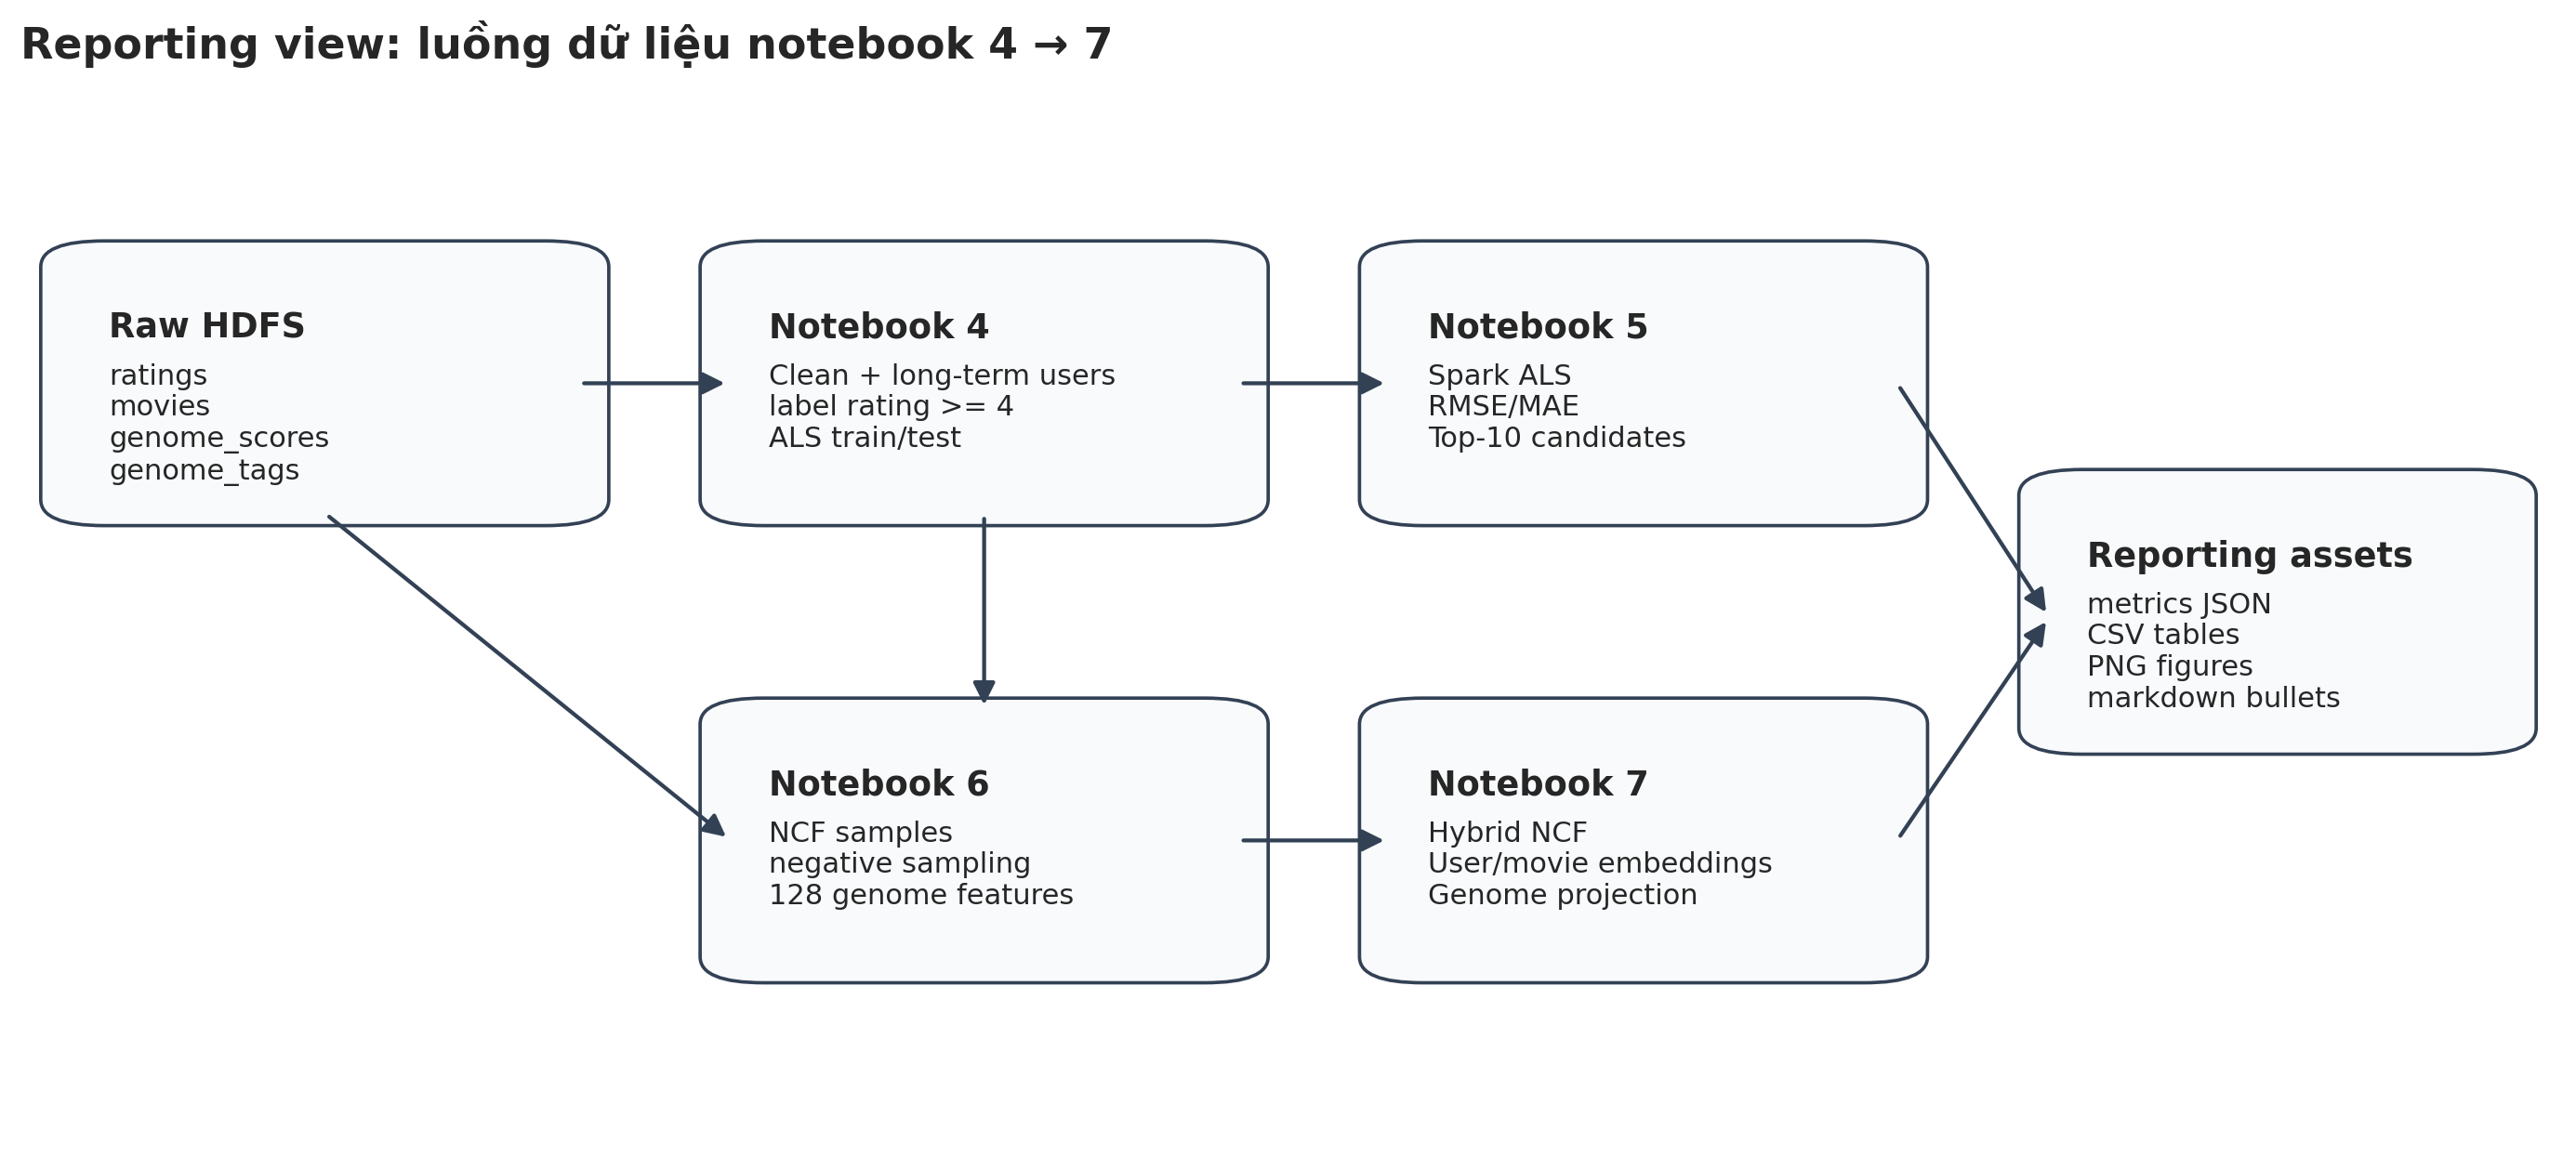

**hdfs_modeling_dataset_row_counts_logscale**

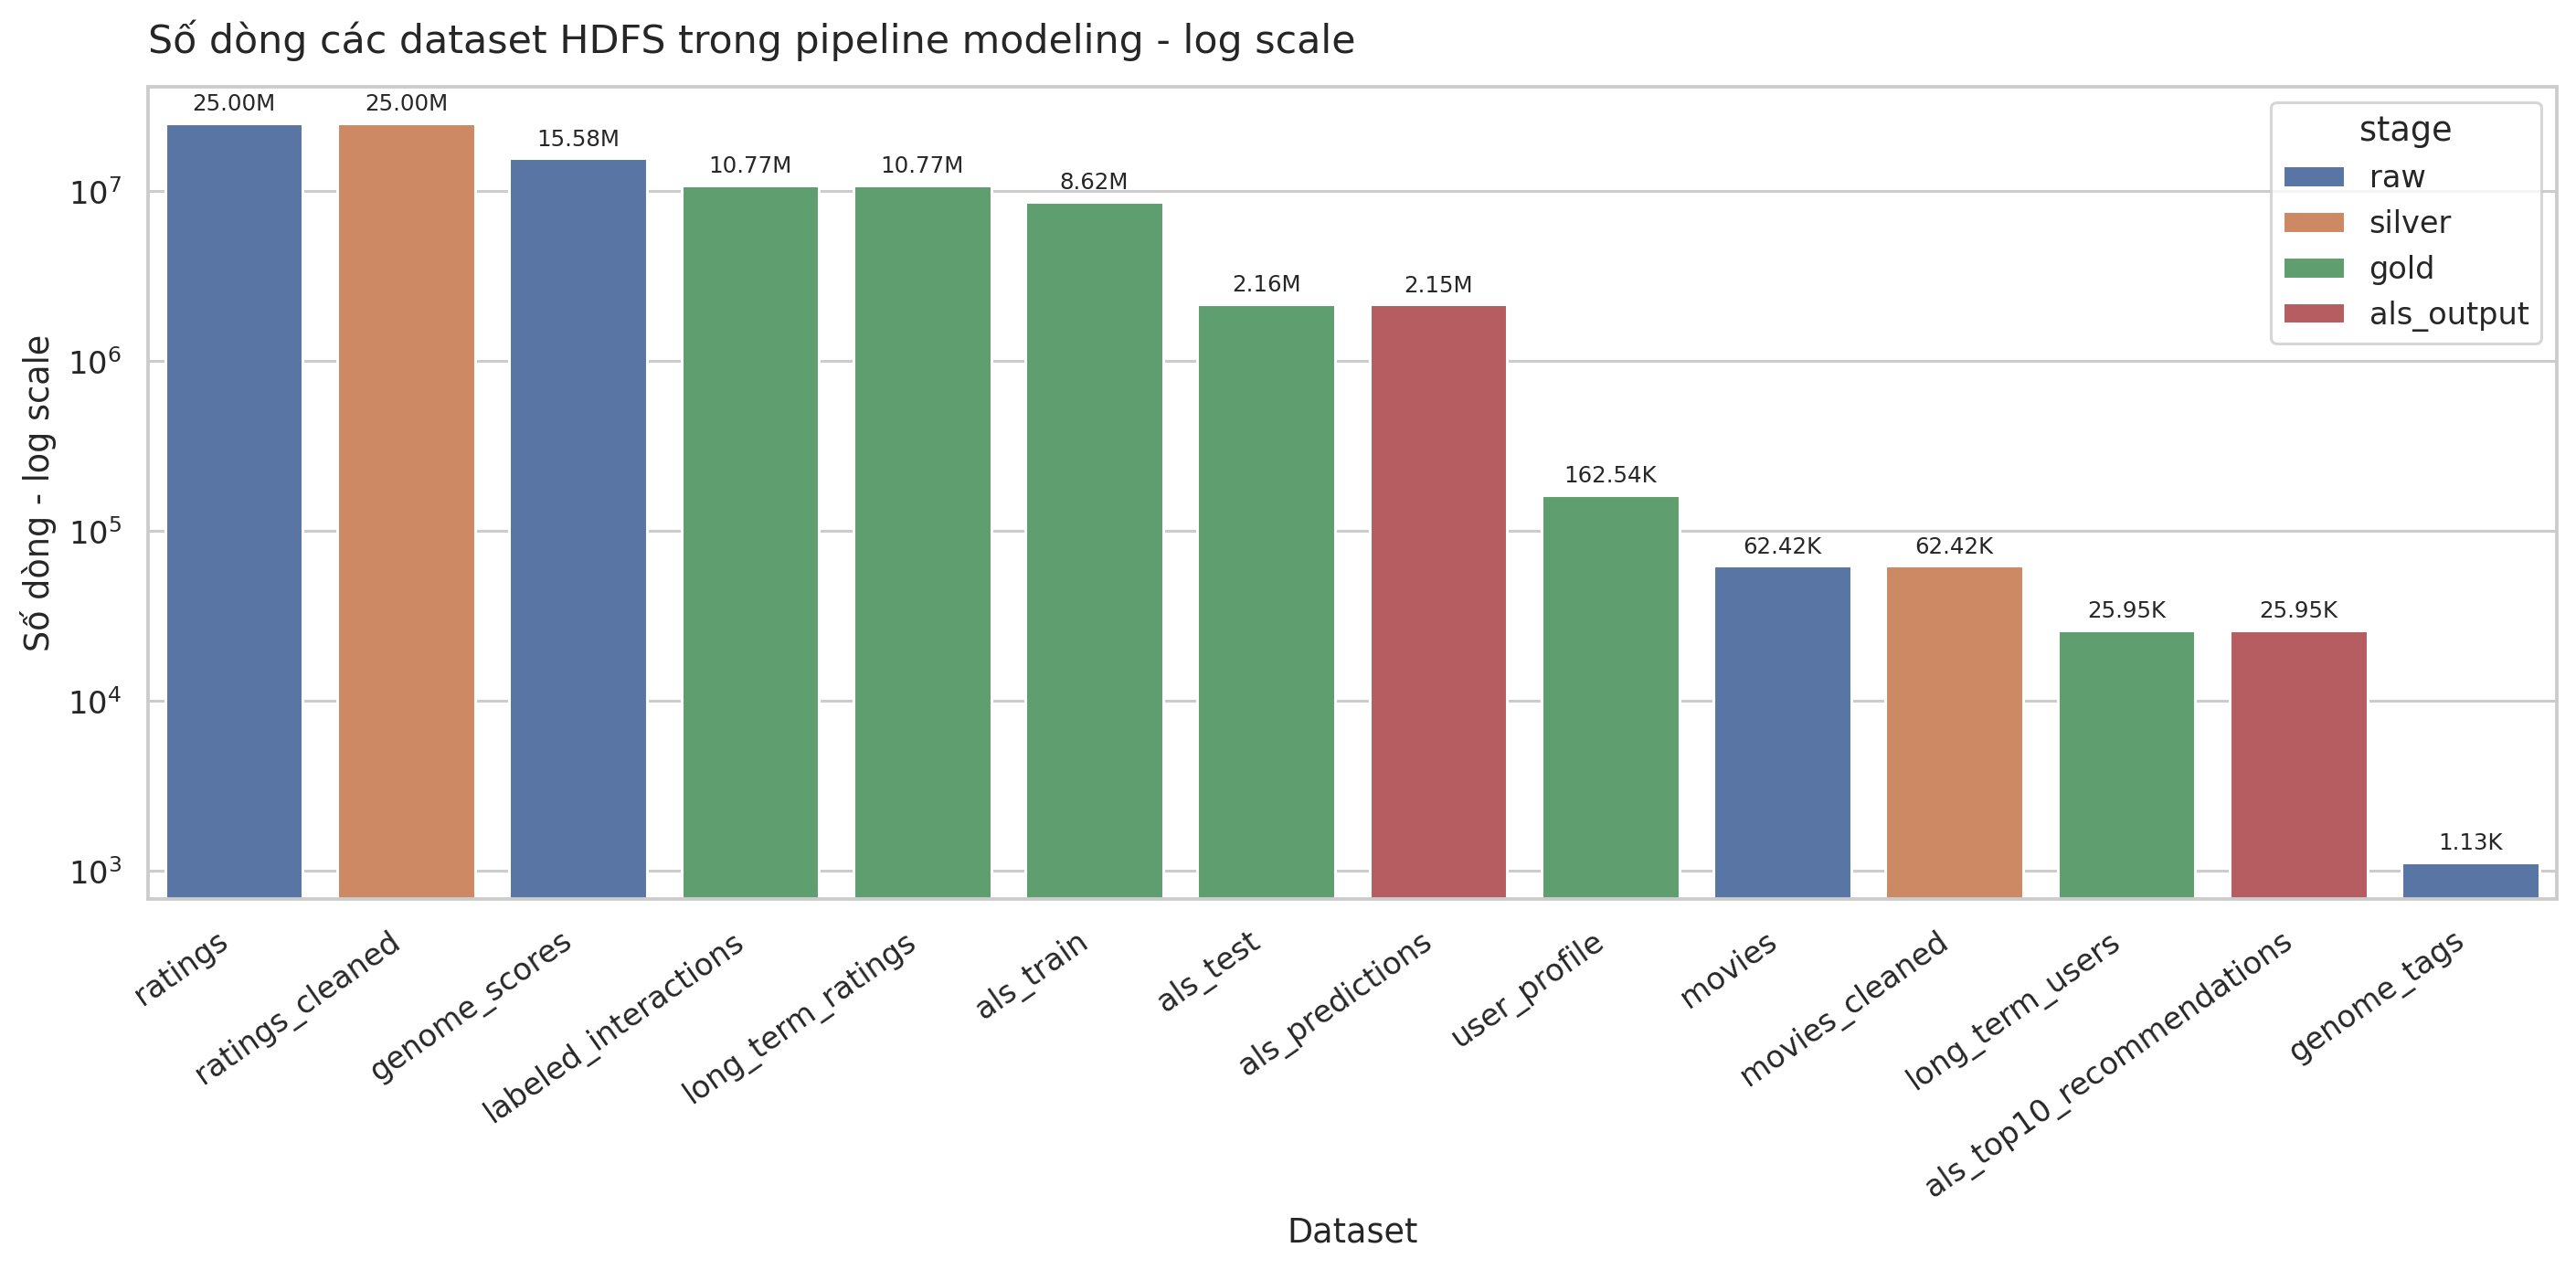

**preprocessing_feature_engineering_kpis_table**

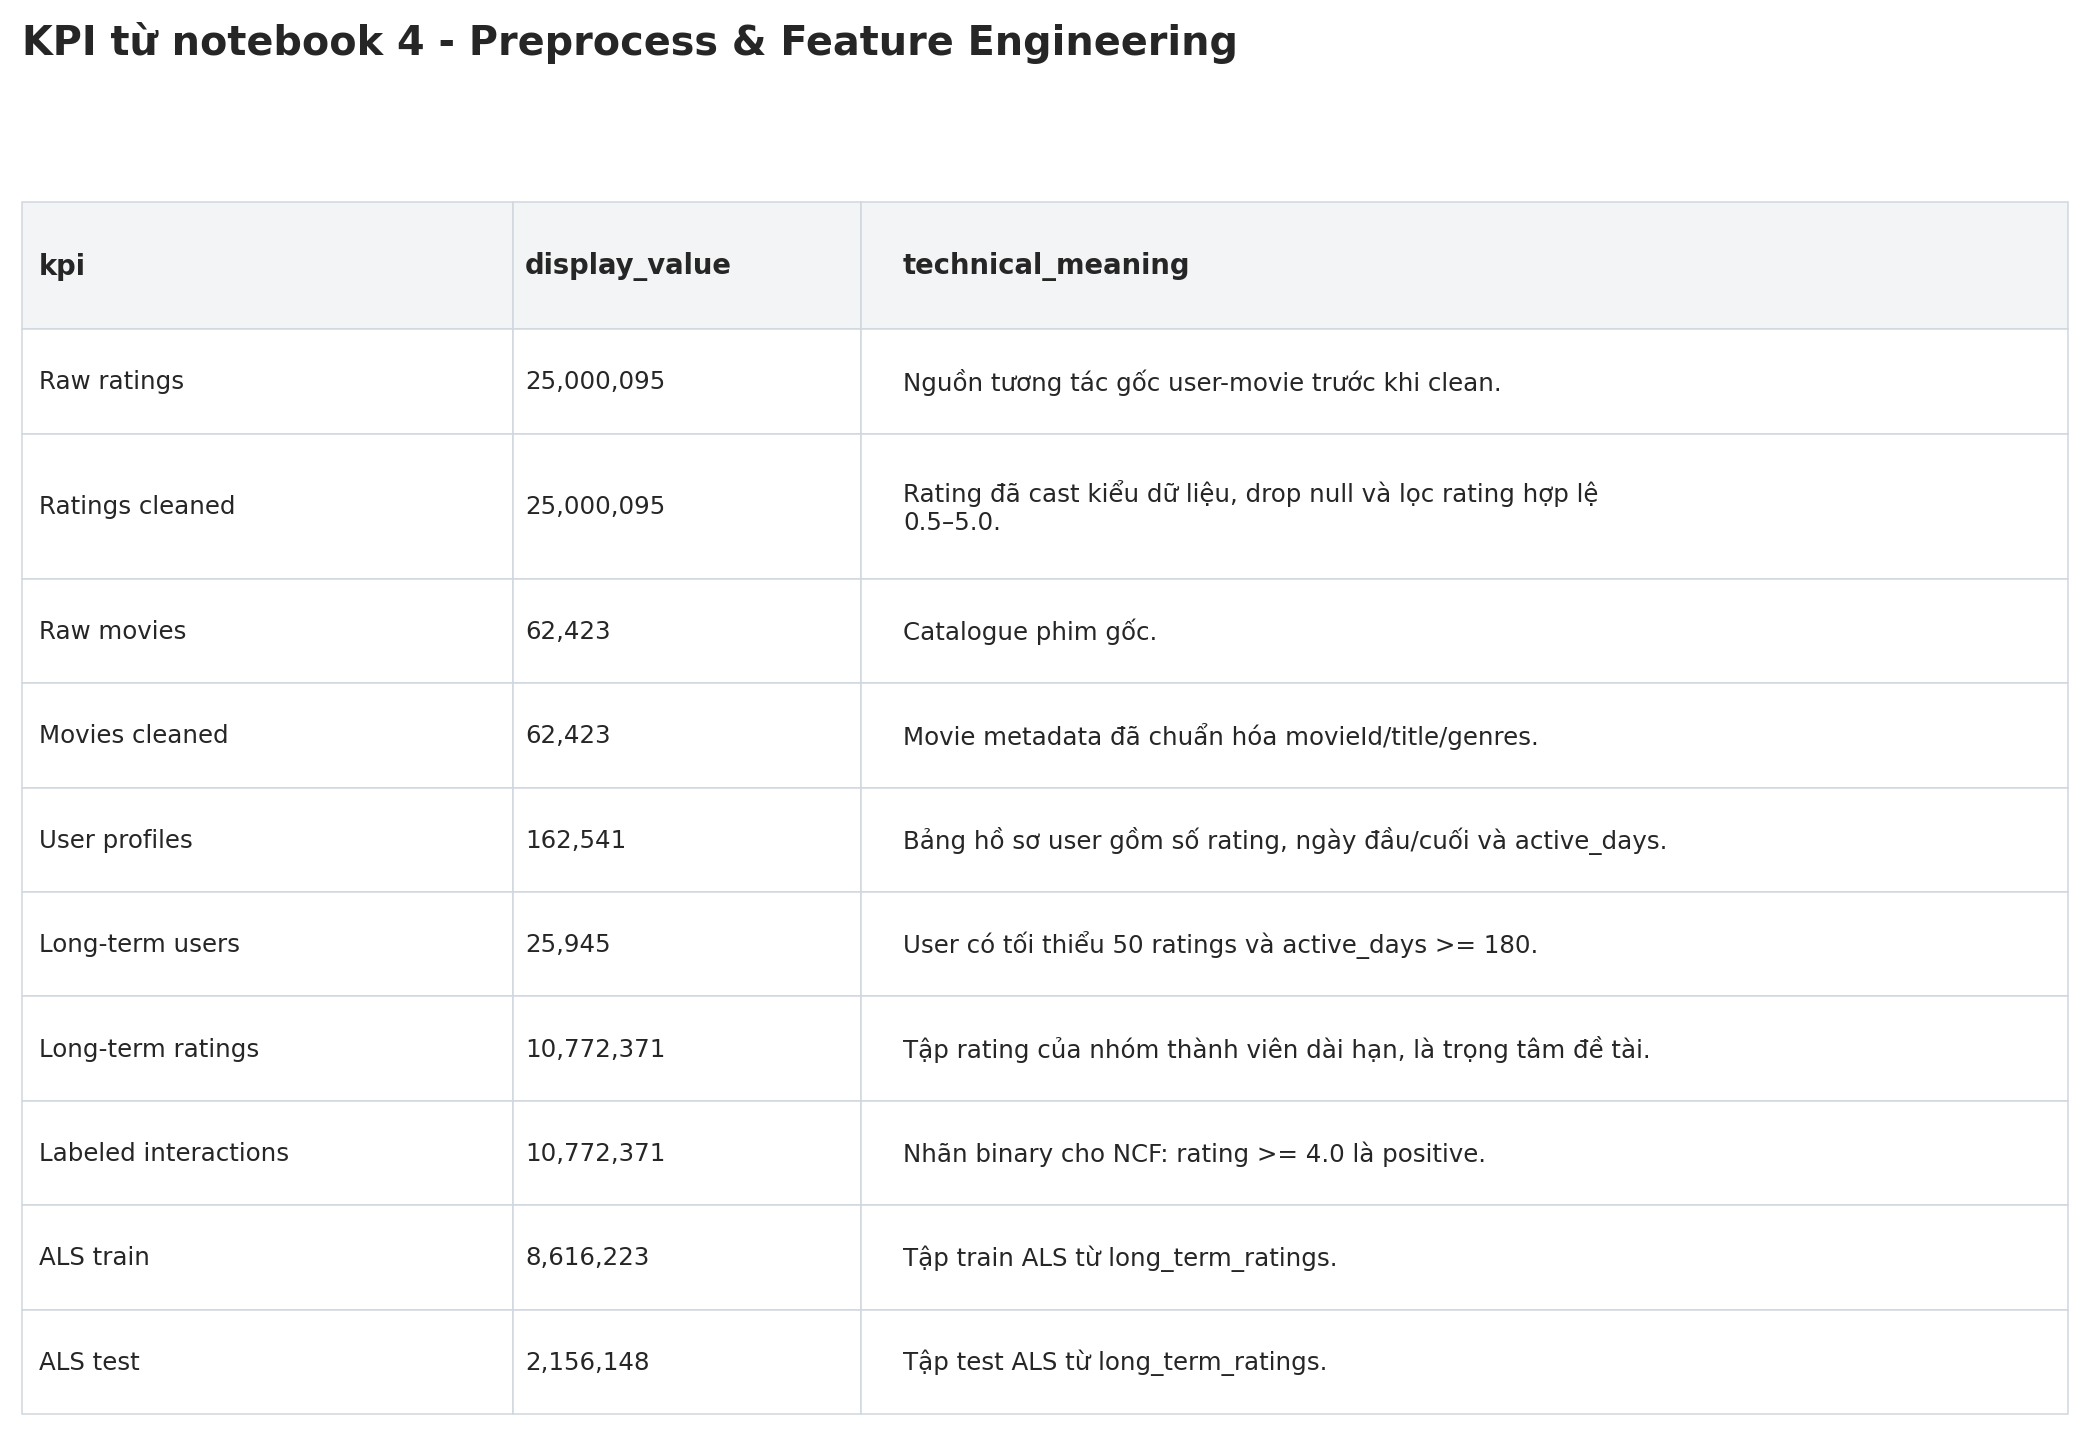

**als_rmse_mae_bar**

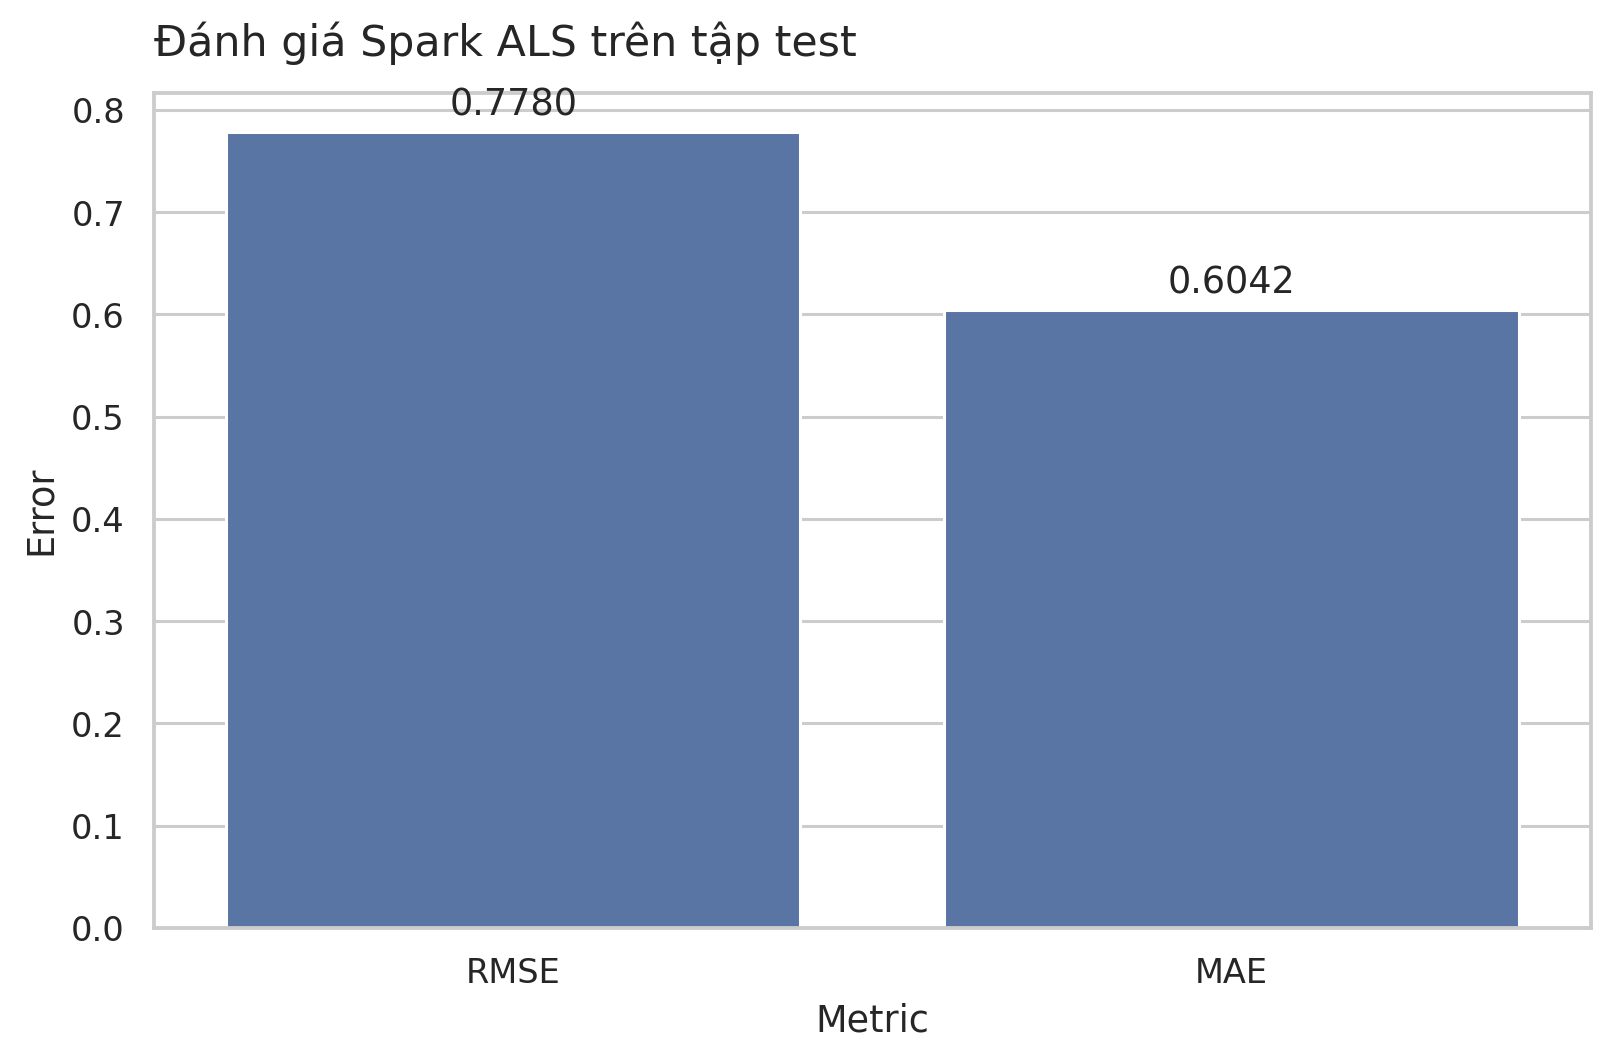

**ncf_train_test_label_balance_bar**

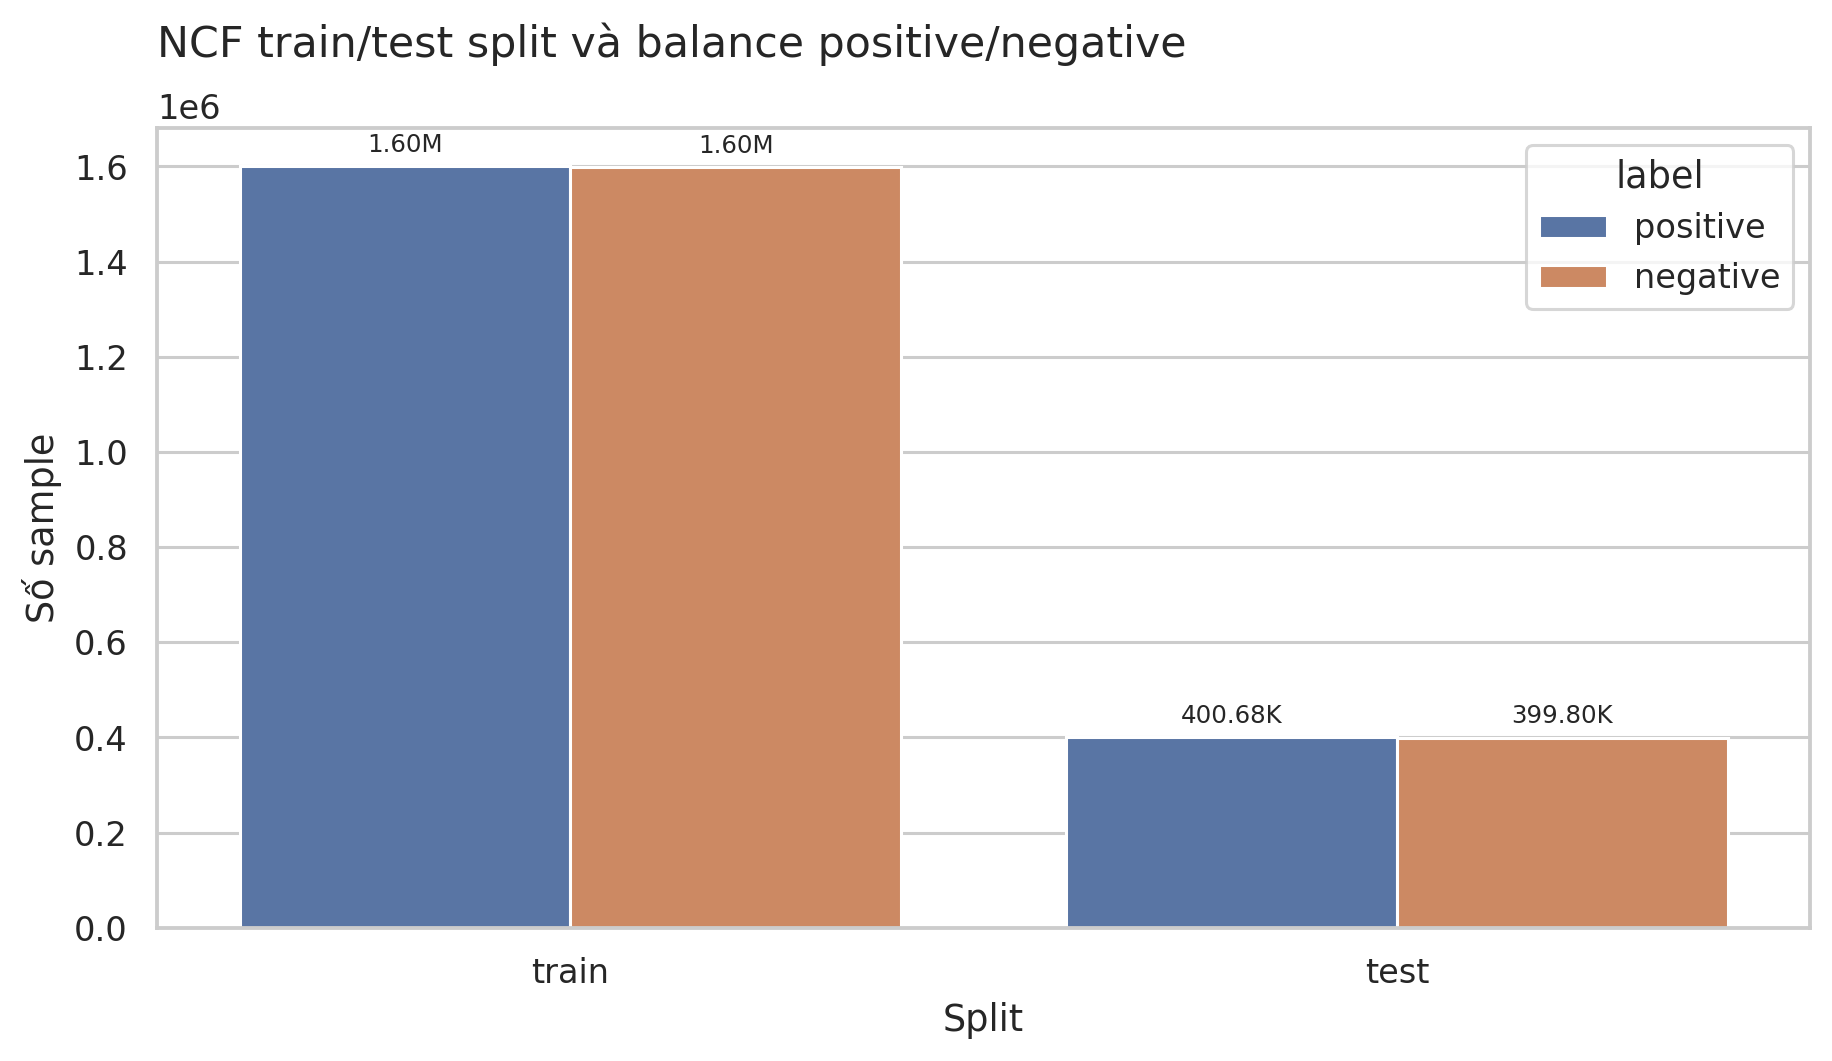

**movie_genome_feature_matrix_sample_heatmap**

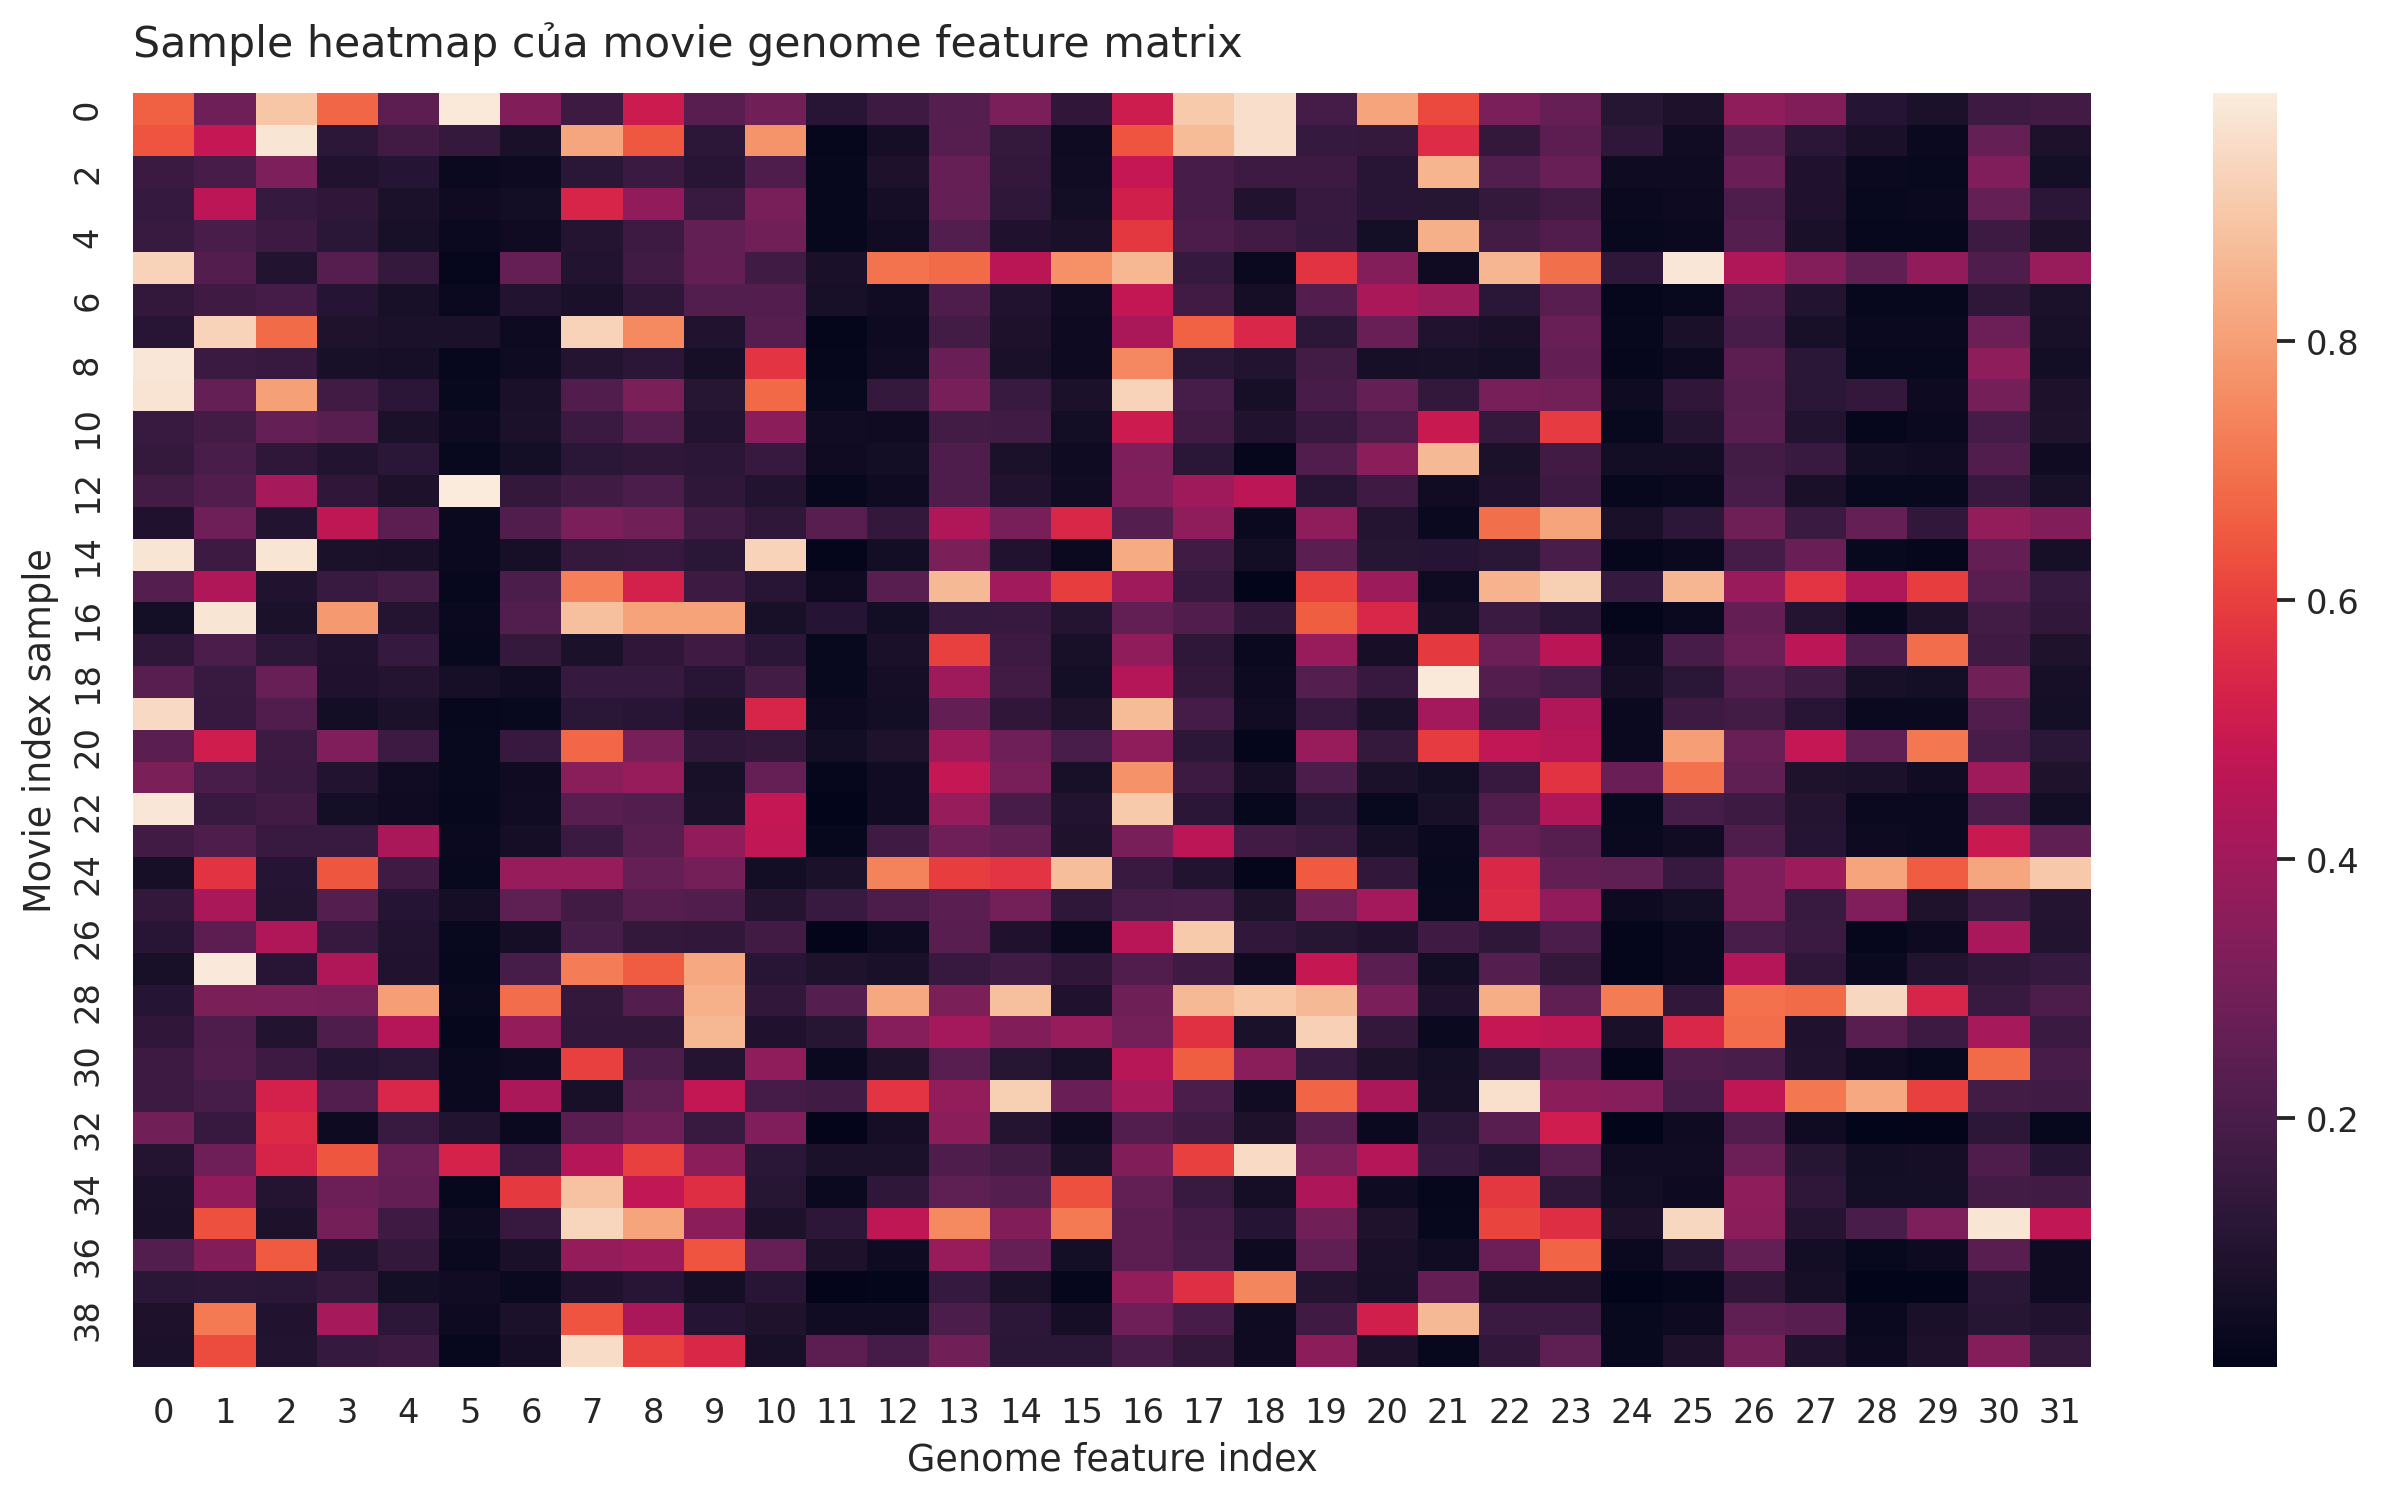

**ncf_accuracy_auc_bar**

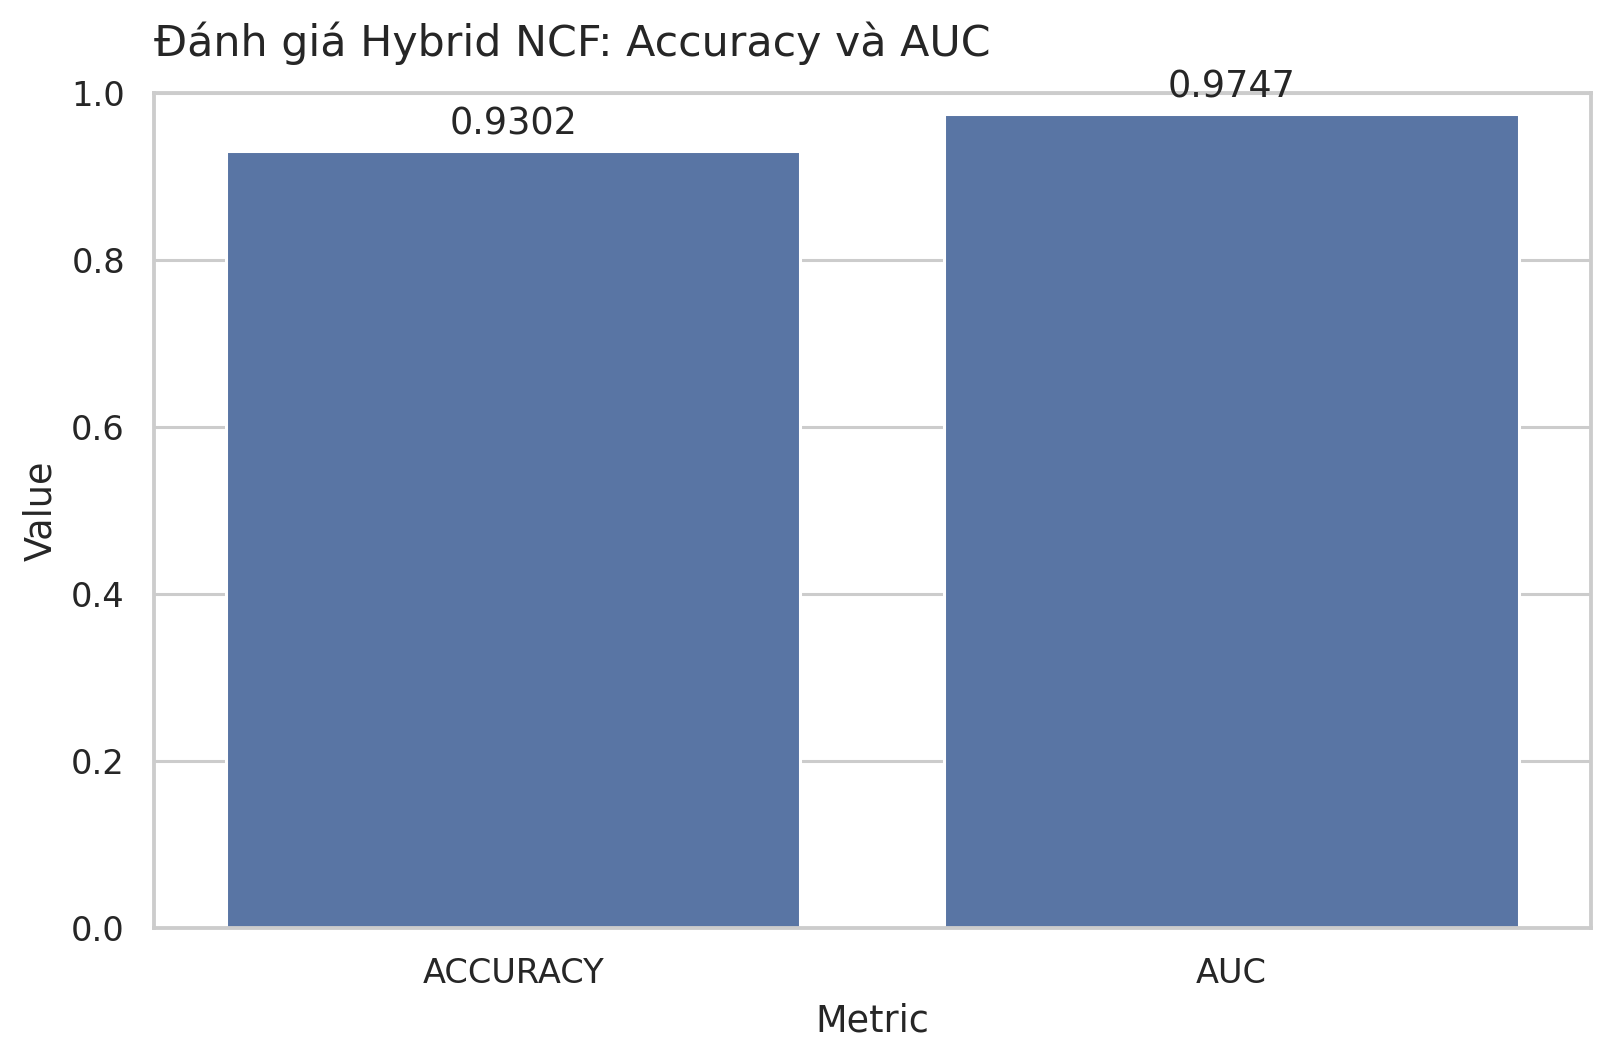

**modeling_report_storyboard_table**

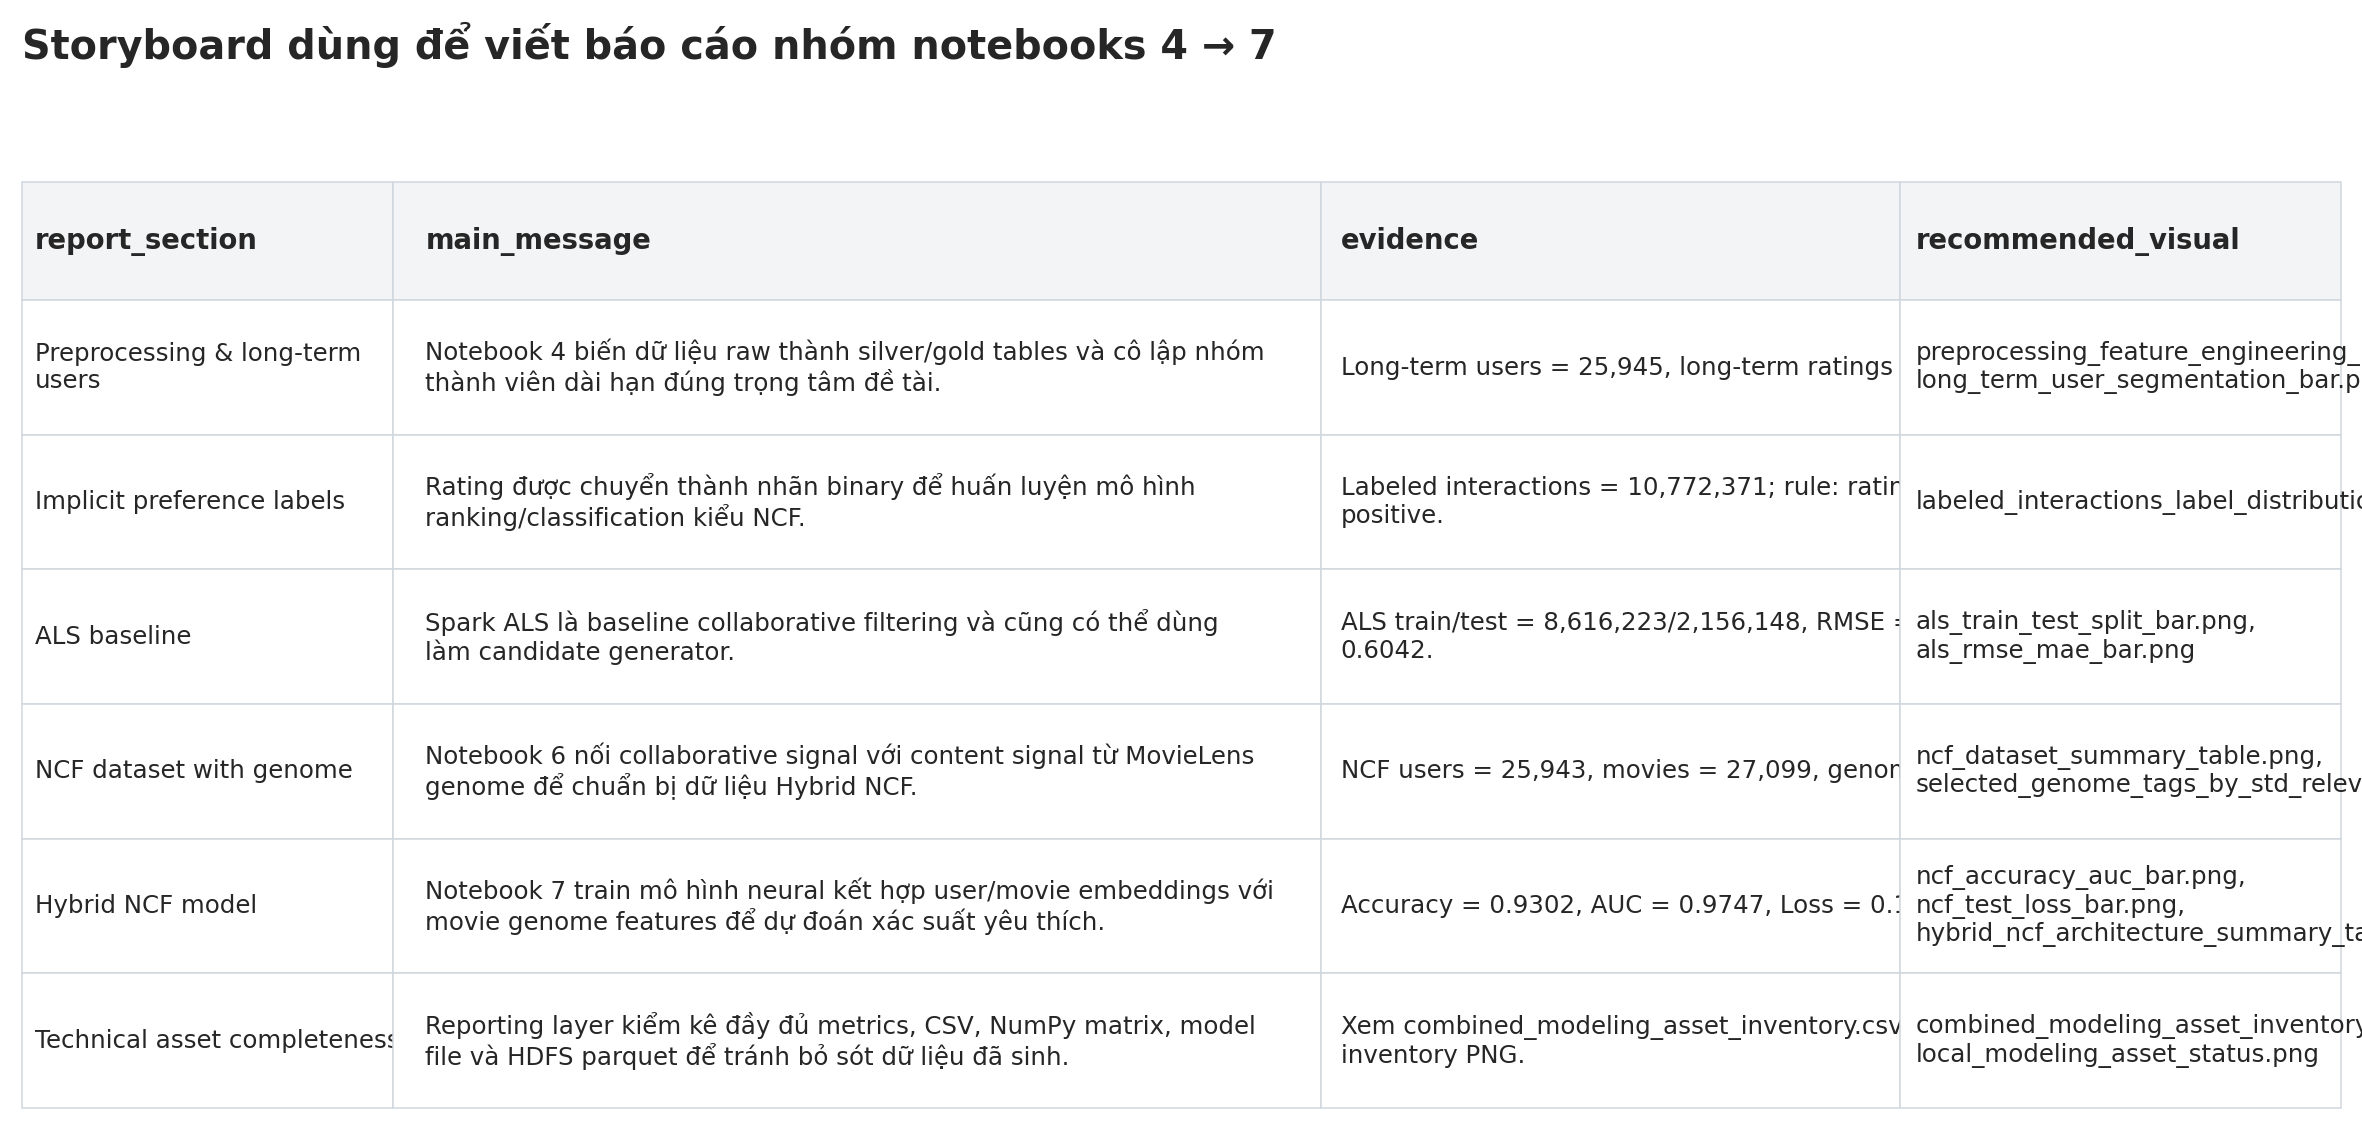

Done. Reporting assets saved to: /workspace/outputs/reporting/reporting_layer_4_5_6_7_modeling_pipeline


In [12]:
manifest = {
    "report_slug": REPORT_SLUG,
    "generated_at": datetime.now().isoformat(timespec="seconds"),
    "spark_status": spark_status,
    "figures": figure_exports,
    "tables": table_exports,
    "metrics": metric_exports,
    "main_output_dir": str(REPORT_DIR),
}

save_json(manifest, METRIC_DIR / "reporting_layer_4_5_6_7_manifest.json")

manifest_df = pd.DataFrame(
    [{"asset_type": "figure", "name": k, "path": v} for k, v in figure_exports.items()] +
    [{"asset_type": "table", "name": k, "path": v} for k, v in table_exports.items()] +
    [{"asset_type": "metric", "name": k, "path": v} for k, v in metric_exports.items()]
)
save_table(manifest_df, "reporting_layer_4_5_6_7_manifest")
display_df(manifest_df, "Generated reporting assets", max_rows=100)

preview_figures([
    "modeling_pipeline_architecture_flow",
    "hdfs_modeling_dataset_row_counts_logscale",
    "preprocessing_feature_engineering_kpis_table",
    "als_rmse_mae_bar",
    "ncf_train_test_label_balance_bar",
    "movie_genome_feature_matrix_sample_heatmap",
    "ncf_accuracy_auc_bar",
    "modeling_report_storyboard_table",
])

print("Done. Reporting assets saved to:", REPORT_DIR)